# Hub&MS2 Figure Generator!

## 0. Importing dependencies and dataset to analyze. 

In [101]:
# dependent packages 

import os, ast, re
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import glob
from scipy.stats import pearsonr

#import interp1d
from scipy.interpolate import interp1d

In [102]:
# figure output directory
figdir = '/Volumes/mirlab/S/Analysis/20241202_Emilia/Figures'

#ensure figdir exists
if not os.path.exists(figdir):
    os.makedirs(figdir)

In [103]:
# open merged data csv
merged_csv_path = "/Volumes/mirlab/S/Analysis/20241202_Emilia/ALL_Analysis/merged_measurements.csv"
merged_df = pd.read_csv(merged_csv_path)

# Create a unique label for each combination of Filename, NC, and Label
merged_df['Unique_Label'] = merged_df.apply(lambda row: f"{row['Filename']}_{row['NC']}_{row['Label']}", axis=1)

def update_gene_label(row):
    if 'Downstream' in row['Unique_Label']:
        return 'downstream'
    elif 'Upstream' in row['Unique_Label']:
        return 'upstream'

merged_df['Gene'] = merged_df.apply(update_gene_label, axis=1)
# print unique values of the Gene column
print(merged_df['Gene'].unique())

# Save the merged DataFrame to a new CSV file
merged_csv_path = "/Volumes/mirlab/S/Analysis/20241202_Emilia/ALL_Analysis/merged_measurements.csv"
merged_df.to_csv(merged_csv_path, index=False)

#list all the columns just for reference
merged_df.columns

['downstream' 'upstream']


Index(['Filename', 'Frame', 'Label', 'Mean_Nuclear_Intensity',
       'Mean_Raw_Nuclear_Intensity', 'Number_of_Hubs', 'Nucleus_Volume',
       'Nuclear_Percentiles [75, 90, 95, 96, 97, 98, 99, 99.9]',
       'Raw_Nuclear_Percentiles [75, 90, 95, 96, 97, 98, 99, 99.9]',
       'Percentage_Volume_in_Hubs', 'Hub_Intensities', 'Hub_Volumes',
       'Normalized_Hub_Volumes', 'Normalized_Hub_Intensities',
       'Raw_Hub_Intensities', 'Raw_Normalized_Hub_Intensities', 'NC',
       'Axis Position', 'Gene', 'Z_MS2', 'Y_MS2', 'X_MS2', 'Linked', 'Ttrack',
       'TrackID', 'DisplacementFromPrior', 'NetSquareDisplacement',
       'Overlap_Pixels', 'Mean_Intensity_B', 'Mean_Intensity',
       'Distance_to_Hub', 'Num_Overlapping_Hubs', 'Binary_Overlap',
       'Binary_Intensity', 'Binary_Distance', 'Smoothed_Overlap_Pixels',
       'Smoothed_Mean_Intensity_B', 'Smoothed_Mean_Intensity',
       'MS2_Start_Frame', 'Burst_Threshold', 'Nuclear_Mean_Raw',
       'Nuclear_Mean_RawB', 'Random_Mean_Raw',
 

In [104]:
#only keep rows where Smoothed_Mean_Intensity is not NaN
merged_df = merged_df[~merged_df['Smoothed_Mean_Intensity'].isna()]

### Style & Color Guide

In [105]:
# Style Guide for these figures
# Remove the dark background style
plt.style.use('default')

# Define colors for each gene 
gene_colors = {
    'downstream': '#029392',  # Teal
    'upstream': '#9ccb86',  # Green
    # 'sog': '#ce597e',  # Reddish
    # 'hunchback_l': '#eeb478'  # Magenta
}

### Dorsal Intensity @ Genes of Interest

#### time series

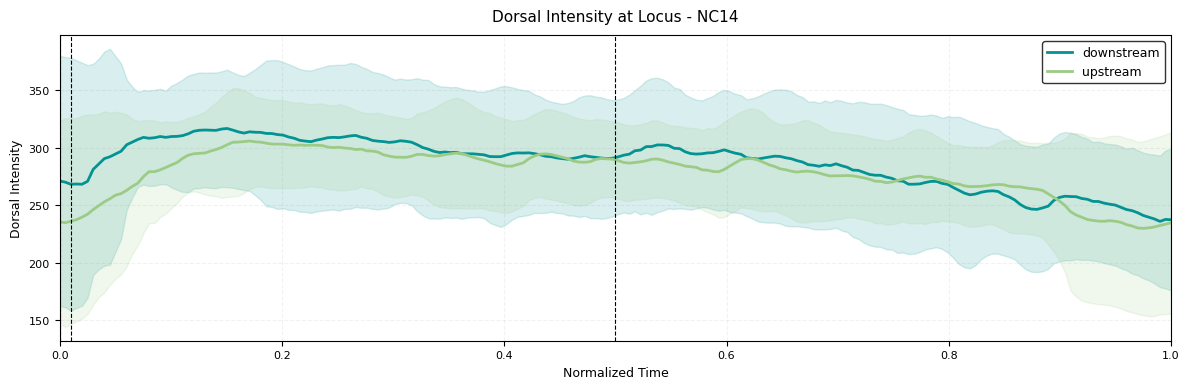

In [106]:
#Time Series 
measure = 'Mean_Intensity'

# Define genes and nuclear cycles
genes = ['snail', 'hunchback_v', 'sog', 'hunchback_l']
genes = ['downstream', 'upstream']
# ncs = ['NC13', 'NC14'] # only plot NC13 and NC14


# Smooth the data before resampling
merged_df[f'Smoothed_{measure}'] = merged_df.groupby('Unique_Label')[f'Smoothed_{measure}'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
merged_df['Smoothed_Nuclear_Mean_Raw'] = merged_df.groupby('Unique_Label')['Nuclear_Mean_Raw'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# Normalize time for each Unique_Label
merged_df['Normalized_Time'] = merged_df.groupby('Unique_Label')['Frame'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# Define the number of points and relative widths for each nuclear cycle
# n_points_dict = {'NC13': 100, 'NC14': 200}
# width_ratios = [100, 200]  # Proportional widths for NC12, NC13, NC14

# Function to resample individual traces to the common time grid
def resample_trace(group, time_grid):
    # Interpolate the data
    f = interp1d(group['Normalized_Time'],
                 group[f'Smoothed_{measure}'],
                 bounds_error=False,
                 kind='nearest',
                 fill_value='extrapolate')
    # Resample to common time grid
    resampled = f(time_grid)
    return pd.Series(resampled, index=time_grid)

# Create figure with pure white background and specified width ratios
fig, axes = plt.subplots(nrows=1, ncols=len(ncs), figsize=(12, 4), 
                        gridspec_kw={'width_ratios': width_ratios})
fig.patch.set_facecolor('white')

# Function to find rise, peak, and fall time points for an individual trace
def find_time_points(group, time_grid):
  
    # Interpolate the data
    f = interp1d(group['Normalized_Time'],
                    group['Smoothed_Nuclear_Mean_Raw'],
                    bounds_error=False,
                    kind='nearest',
                    fill_value='extrapolate')
        # Resample to common time grid
    resampled = f(time_grid)
    resampled_trace = pd.Series(resampled, index=time_grid)

    # Find peak time point
    peak_time = resampled_trace.idxmax()
    
    # Find rise time point (midway between 0 and peak)
    rise_time = (peak_time / 2) - 0.015
    rise_time = (peak_time / 2)
    rise_time = 0.01
    # Find fall time point (halfway between peak and end of time = 1)
    # fall_time = ((peak_time + 1) / 2) - 0.1
    fall_time = ((peak_time + 1) / 2)
    return pd.Series({'rise_time': rise_time, 'peak_time': peak_time, 'fall_time': fall_time})

# Iterate through each NC
for j, nc in enumerate(ncs):
    # Create a consistent time grid for resampling
    n_points = n_points_dict[nc]
    time_grid = np.linspace(0, 1, n_points)
    
    # Filter data for current NC
    nc_data = merged_df[merged_df['NC'] == nc]
    
     # Get time points for the mean trace
    all_gene_data = nc_data
    resampled_traces_combined = []
    time_points_combined = []
    for name, group in all_gene_data.groupby('Unique_Label'):
      resampled = resample_trace(group, time_grid)
      resampled_traces_combined.append(resampled)
      #find time points
      trace_time_points = find_time_points(group,time_grid)
      time_points_combined.append(trace_time_points)

    # Calculate the mean rise, peak, and fall times
    time_points_df = pd.concat(time_points_combined, axis=1).T
    mean_rise_time = time_points_df['rise_time'].mean()
    mean_peak_time = time_points_df['peak_time'].mean()
    mean_fall_time = time_points_df['fall_time'].mean()
    
    # Process each gene separately
    for gene in genes:
        # Filter for gene type
        gene_data = nc_data[nc_data['Gene'] == gene]
        
        # Resample each unique label's trace
        resampled_traces = []
        for name, group in gene_data.groupby('Unique_Label'):
            resampled = resample_trace(group, time_grid)
            resampled_traces.append(resampled)
            
        # Stack all resampled traces
        all_traces = pd.concat(resampled_traces, axis=1)
        
        # Calculate mean and std across traces
        mean_trace = all_traces.mean(axis=1)
        std_trace = all_traces.std(axis=1)
        
        # Apply final smoothing if desired
        window = 1
        mean_trace_smooth = pd.Series(mean_trace).rolling(window=window, center=True, min_periods=1).mean()
        std_trace_smooth = pd.Series(std_trace).rolling(window=window, center=True, min_periods=1).mean()
        
        # Plot
        ax = axes
        ax.set_facecolor('white')
        
        ax.plot(time_grid, mean_trace_smooth, label=gene, color=gene_colors[gene], linewidth=2)
        ax.fill_between(time_grid,
                       mean_trace_smooth - std_trace_smooth,
                       mean_trace_smooth + std_trace_smooth,
                       color=gene_colors[gene], alpha=0.15)
    
    # Add vertical lines at mean rise, peak, and fall times
    ax.axvline(x=mean_rise_time, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(x=mean_peak_time, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(x=mean_fall_time, color='black', linestyle='--', linewidth=0.8)
    
    
    # Style the subplot
    ax.set_title(f'Dorsal Intensity at Locus - {nc}', color='black', pad=10, fontsize=11)
    ax.set_xlabel('Normalized Time', color='black', fontsize=9)
    ax.set_ylabel('Dorsal Intensity', color='black', fontsize=9)
    
    # Style the grid
    ax.grid(True, linestyle='--', alpha=0.1, color='gray')
    
    # Style the spines
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.8)
        
    # Style the ticks
    ax.tick_params(colors='black', width=0.8, labelsize=8)
    
    # Style the legend
    ax.legend(framealpha=0.8, facecolor='white', edgecolor='black', 
             fontsize=9, loc='upper right')
    
    # Ensure x limits are 0-1
    ax.set_xlim(0,1)
    # ax.set_ylim(0, 325)

plt.tight_layout()

# Add some padding around the subplots
plt.subplots_adjust(wspace=0.3)
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F2'
# plt.savefig(os.path.join(figdir, 'dorsal_intensity_time_series.svg'), format='svg', dpi=300)
plt.show()

### Hub Area Overlap

#### time series

/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/492649881.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df[f'Smoothed_{measure}'] = merged_df.groupby('Unique_Label')[f'Smoothed_{measure}'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/492649881.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Smoothed_Nuclear_Mean_Raw'] = merged_df.groupby('Unique_Label')['Nuclear_Mean_Raw'].transf

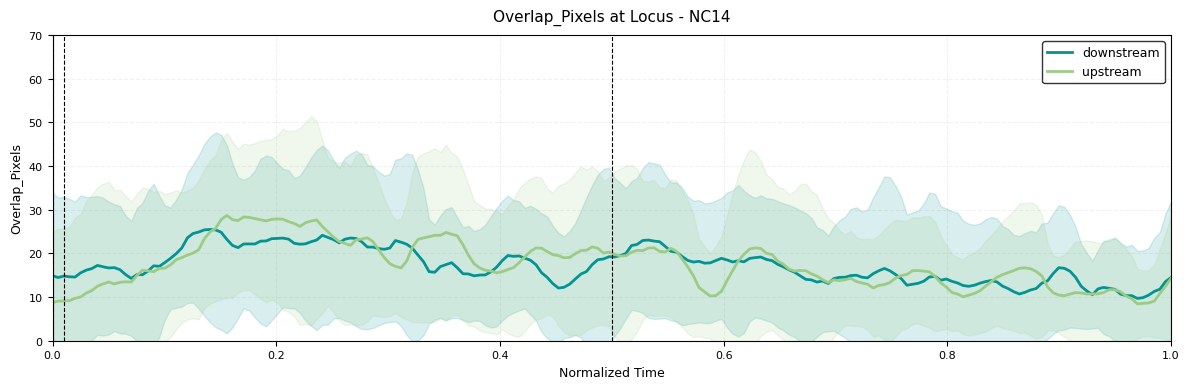

In [49]:
#Time Series 
measure = 'Overlap_Pixels'

# Define genes and nuclear cycles
# genes = ['snail', 'hunchback_v', 'sog', 'hunchback_l']
# ncs = ['NC13', 'NC14'] # only plot NC13 and NC14


# Smooth the data before resampling
merged_df[f'Smoothed_{measure}'] = merged_df.groupby('Unique_Label')[f'Smoothed_{measure}'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
merged_df['Smoothed_Nuclear_Mean_Raw'] = merged_df.groupby('Unique_Label')['Nuclear_Mean_Raw'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# Normalize time for each Unique_Label
merged_df['Normalized_Time'] = merged_df.groupby('Unique_Label')['Frame'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# # Define the number of points and relative widths for each nuclear cycle
# n_points_dict = {'NC13': 100, 'NC14': 200}
# width_ratios = [100, 200]  # Proportional widths for NC12, NC13, NC14

# Function to resample individual traces to the common time grid
def resample_trace(group, time_grid):
    # Interpolate the data
    f = interp1d(group['Normalized_Time'],
                 group[f'Smoothed_{measure}'],
                 bounds_error=False,
                 kind='nearest',
                 fill_value='extrapolate')
    # Resample to common time grid
    resampled = f(time_grid)
    return pd.Series(resampled, index=time_grid)

# Create figure with pure white background and specified width ratios
fig, axes = plt.subplots(nrows=1, ncols=len(ncs), figsize=(12, 4), 
                        gridspec_kw={'width_ratios': width_ratios})
fig.patch.set_facecolor('white')

# Function to find rise, peak, and fall time points for an individual trace
def find_time_points(group, time_grid):
  
    # Interpolate the data
    f = interp1d(group['Normalized_Time'],
                    group['Smoothed_Nuclear_Mean_Raw'],
                    bounds_error=False,
                    kind='nearest',
                    fill_value='extrapolate')
        # Resample to common time grid
    resampled = f(time_grid)
    resampled_trace = pd.Series(resampled, index=time_grid)

    # Find peak time point
    peak_time = resampled_trace.idxmax()
    
    # Find rise time point (midway between 0 and peak)
    rise_time = (peak_time / 2) - 0.015
    rise_time = (peak_time / 2)
    rise_time = 0.01
    # Find fall time point (halfway between peak and end of time = 1)
    # fall_time = ((peak_time + 1) / 2) - 0.1
    fall_time = ((peak_time + 1) / 2)
    return pd.Series({'rise_time': rise_time, 'peak_time': peak_time, 'fall_time': fall_time})

# Iterate through each NC
for j, nc in enumerate(ncs):
    # Create a consistent time grid for resampling
    n_points = n_points_dict[nc]
    time_grid = np.linspace(0, 1, n_points)
    
    # Filter data for current NC
    nc_data = merged_df[merged_df['NC'] == nc]
    
     # Get time points for the mean trace
    all_gene_data = nc_data
    resampled_traces_combined = []
    time_points_combined = []
    for name, group in all_gene_data.groupby('Unique_Label'):
      resampled = resample_trace(group, time_grid)
      resampled_traces_combined.append(resampled)
      #find time points
      trace_time_points = find_time_points(group,time_grid)
      time_points_combined.append(trace_time_points)

    # Calculate the mean rise, peak, and fall times
    time_points_df = pd.concat(time_points_combined, axis=1).T
    mean_rise_time = time_points_df['rise_time'].mean()
    mean_peak_time = time_points_df['peak_time'].mean()
    mean_fall_time = time_points_df['fall_time'].mean()
    
    # Process each gene separately
    for gene in genes:
        # Filter for gene type
        gene_data = nc_data[nc_data['Gene'] == gene]
        
        # Resample each unique label's trace
        resampled_traces = []
        for name, group in gene_data.groupby('Unique_Label'):
            resampled = resample_trace(group, time_grid)
            resampled_traces.append(resampled)
            
        # Stack all resampled traces
        all_traces = pd.concat(resampled_traces, axis=1)
        
        # Calculate mean and std across traces
        mean_trace = all_traces.mean(axis=1)
        std_trace = all_traces.std(axis=1)
        
        # Apply final smoothing if desired
        window = 1
        mean_trace_smooth = pd.Series(mean_trace).rolling(window=window, center=True, min_periods=1).mean()
        std_trace_smooth = pd.Series(std_trace).rolling(window=window, center=True, min_periods=1).mean()
        
        # Plot
        ax = axes
        ax.set_facecolor('white')
        
        ax.plot(time_grid, mean_trace_smooth, label=gene, color=gene_colors[gene], linewidth=2)
        ax.fill_between(time_grid,
                       mean_trace_smooth - std_trace_smooth,
                       mean_trace_smooth + std_trace_smooth,
                       color=gene_colors[gene], alpha=0.15)
    
    # Add vertical lines at mean rise, peak, and fall times
    ax.axvline(x=mean_rise_time, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(x=mean_peak_time, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(x=mean_fall_time, color='black', linestyle='--', linewidth=0.8)
    
    
    # Style the subplot
    ax.set_title(f'{measure} at Locus - {nc}', color='black', pad=10, fontsize=11)
    ax.set_xlabel('Normalized Time', color='black', fontsize=9)
    ax.set_ylabel(measure, color='black', fontsize=9)
    
    # Style the grid
    ax.grid(True, linestyle='--', alpha=0.1, color='gray')
    
    # Style the spines
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.8)
        
    # Style the ticks
    ax.tick_params(colors='black', width=0.8, labelsize=8)
    
    # Style the legend
    ax.legend(framealpha=0.8, facecolor='white', edgecolor='black', 
             fontsize=9, loc='upper right')
    
    # Ensure x limits are 0-1
    ax.set_xlim(0,1)
    ax.set_ylim(0, 70)

plt.tight_layout()

# Add some padding around the subplots
plt.subplots_adjust(wspace=0.3)
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F2'
# plt.savefig(os.path.join(figdir, f'{measure}_time_series.svg'), format='svg', dpi=300)
plt.show()

### Overlap Intensity

#### time series

/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/2992202691.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df[f'Smoothed_{measure}'] = merged_df.groupby('Unique_Label')[f'{measure}'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/2992202691.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df[f'Smoothed_{measure}'] = merged_df.groupby('Unique_Label')[f'Smoothed_{measure}'].transform(lambda

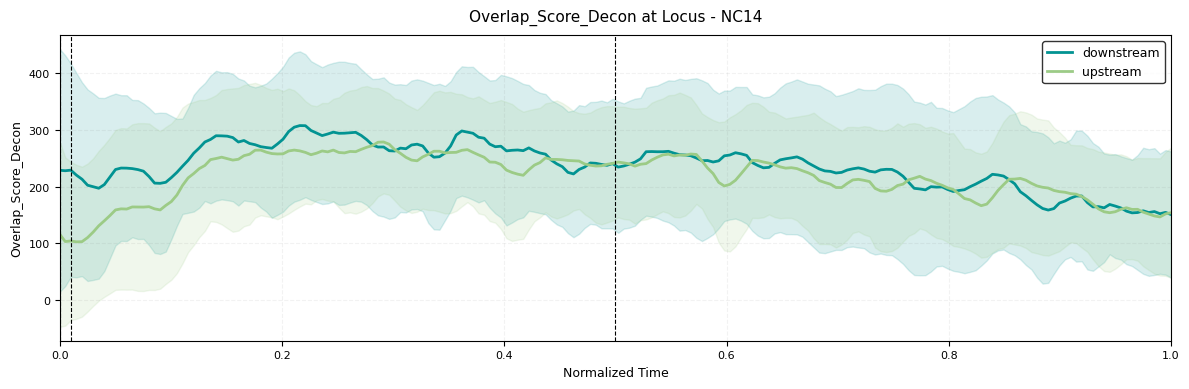

In [55]:
#Time Series 
measure = 'Overlap_Score_Decon'

# Define genes and nuclear cycles
# genes = ['snail', 'hunchback_v', 'sog', 'hunchback_l']
# ncs = ['NC13', 'NC14'] # only plot NC13 and NC14


# Smooth the data before resampling
merged_df[f'Smoothed_{measure}'] = merged_df.groupby('Unique_Label')[f'{measure}'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
merged_df[f'Smoothed_{measure}'] = merged_df.groupby('Unique_Label')[f'Smoothed_{measure}'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
merged_df['Smoothed_Nuclear_Mean_Raw'] = merged_df.groupby('Unique_Label')['Mean_Raw_Nuclear_Intensity'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# Normalize time for each Unique_Label
merged_df['Normalized_Time'] = merged_df.groupby('Unique_Label')['Frame'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# Define the number of points and relative widths for each nuclear cycle
# n_points_dict = {'NC13': 100, 'NC14': 200}
# width_ratios = [100, 200]  # Proportional widths for NC12, NC13, NC14

# Function to resample individual traces to the common time grid
def resample_trace(group, time_grid):
    # Interpolate the data
    f = interp1d(group['Normalized_Time'],
                 group[f'Smoothed_{measure}'],
                 bounds_error=False,
                 kind='nearest',
                 fill_value='extrapolate')
    # Resample to common time grid
    resampled = f(time_grid)
    return pd.Series(resampled, index=time_grid)

# Create figure with pure white background and specified width ratios
fig, axes = plt.subplots(nrows=1, ncols=len(ncs), figsize=(12, 4), 
                        gridspec_kw={'width_ratios': width_ratios})
fig.patch.set_facecolor('white')

# Function to find rise, peak, and fall time points for an individual trace
def find_time_points(group, time_grid):
  
    # Interpolate the data
    f = interp1d(group['Normalized_Time'],
                    group['Smoothed_Nuclear_Mean_Raw'],
                    bounds_error=False,
                    kind='nearest',
                    fill_value='extrapolate')
        # Resample to common time grid
    resampled = f(time_grid)
    resampled_trace = pd.Series(resampled, index=time_grid)

    # Find peak time point
    peak_time = resampled_trace.idxmax()
    
    # Find rise time point (midway between 0 and peak)
    rise_time = (peak_time / 2) - 0.015
    rise_time = (peak_time / 2)
    rise_time = 0.01
    # Find fall time point (halfway between peak and end of time = 1)
    # fall_time = ((peak_time + 1) / 2) - 0.1
    fall_time = ((peak_time + 1) / 2)
    return pd.Series({'rise_time': rise_time, 'peak_time': peak_time, 'fall_time': fall_time})

# Iterate through each NC
for j, nc in enumerate(ncs):
    # Create a consistent time grid for resampling
    n_points = n_points_dict[nc]
    time_grid = np.linspace(0, 1, n_points)
    
    # Filter data for current NC
    nc_data = merged_df[merged_df['NC'] == nc]
    
     # Get time points for the mean trace
    all_gene_data = nc_data
    resampled_traces_combined = []
    time_points_combined = []
    for name, group in all_gene_data.groupby('Unique_Label'):
      resampled = resample_trace(group, time_grid)
      resampled_traces_combined.append(resampled)
      #find time points
      trace_time_points = find_time_points(group,time_grid)
      time_points_combined.append(trace_time_points)

    # Calculate the mean rise, peak, and fall times
    time_points_df = pd.concat(time_points_combined, axis=1).T
    mean_rise_time = time_points_df['rise_time'].mean()
    mean_peak_time = time_points_df['peak_time'].mean()
    mean_fall_time = time_points_df['fall_time'].mean()
    
    # Process each gene separately
    for gene in genes:
        # Filter for gene type
        gene_data = nc_data[nc_data['Gene'] == gene]
        
        # Resample each unique label's trace
        resampled_traces = []
        for name, group in gene_data.groupby('Unique_Label'):
            resampled = resample_trace(group, time_grid)
            resampled_traces.append(resampled)
            
        # Stack all resampled traces
        all_traces = pd.concat(resampled_traces, axis=1)
        
        # Calculate mean and std across traces
        mean_trace = all_traces.mean(axis=1)
        std_trace = all_traces.std(axis=1)
        
        # Apply final smoothing if desired
        window = 1
        mean_trace_smooth = pd.Series(mean_trace).rolling(window=window, center=True, min_periods=1).mean()
        std_trace_smooth = pd.Series(std_trace).rolling(window=window, center=True, min_periods=1).mean()
        
        # Plot
        ax = axes
        ax.set_facecolor('white')
        
        ax.plot(time_grid, mean_trace_smooth, label=gene, color=gene_colors[gene], linewidth=2)
        ax.fill_between(time_grid,
                       mean_trace_smooth - std_trace_smooth,
                       mean_trace_smooth + std_trace_smooth,
                       color=gene_colors[gene], alpha=0.15)
    
    # Add vertical lines at mean rise, peak, and fall times
    ax.axvline(x=mean_rise_time, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(x=mean_peak_time, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(x=mean_fall_time, color='black', linestyle='--', linewidth=0.8)
    
    
    # Style the subplot
    ax.set_title(f'{measure} at Locus - {nc}', color='black', pad=10, fontsize=11)
    ax.set_xlabel('Normalized Time', color='black', fontsize=9)
    ax.set_ylabel(measure, color='black', fontsize=9)
    
    # Style the grid
    ax.grid(True, linestyle='--', alpha=0.1, color='gray')
    
    # Style the spines
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.8)
        
    # Style the ticks
    ax.tick_params(colors='black', width=0.8, labelsize=8)
    
    # Style the legend
    ax.legend(framealpha=0.8, facecolor='white', edgecolor='black', 
             fontsize=9, loc='upper right')
    
    # Ensure x limits are 0-1
    ax.set_xlim(0,1)
    # ax.set_ylim(0, 410)

plt.tight_layout()

# Add some padding around the subplots
plt.subplots_adjust(wspace=0.3)
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F2'
# plt.savefig(os.path.join(figdir, f'{measure}_time_series.svg'), format='svg', dpi=300)
plt.show()

### Duration/Survival/Lifetime

#### box plots

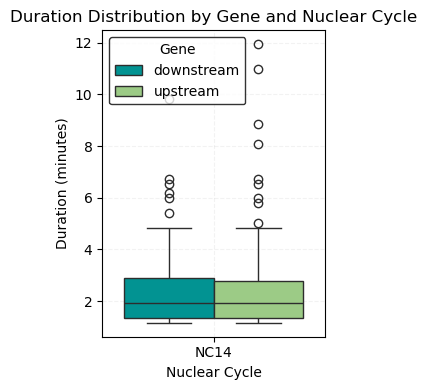

In [60]:
# Box Plots

# Function to calculate consecutive durations of non-zero values with a gap of at least two frames
def calculate_consecutive_durations(series):
    durations = []
    current_duration = 0
    gap = 0
    for value in series:
        if value > 0:
            if gap >= 1:
                if current_duration > 0:
                    durations.append(current_duration)
                current_duration = 1
                gap = 0
            else:
                current_duration += 1
        else:
            gap += 1
            if current_duration > 0 and gap >= 1:
                durations.append(current_duration)
                current_duration = 0
    if current_duration > 0:
        durations.append(current_duration)
    return durations

# Initialize an empty list to store the results
results = []

# Iterate through each unique label
for label in merged_df['Unique_Label'].unique():
    trace = merged_df[merged_df['Unique_Label'] == label]
    trace = trace.dropna(subset=['Overlap_Pixels'])  # Remove NaNs
    durations = calculate_consecutive_durations(trace['Overlap_Pixels'])
    for duration in durations:
        results.append({
            'Filename': trace['Filename'].iloc[0],
            'Unique_Label': label,
            'Gene': trace['Gene'].iloc[0],
            'NC': trace['NC'].iloc[0],
            'Duration': duration * 11.56 / 60  # Convert frames to minutes
        })

# Create a DataFrame from the results
durations_df = pd.DataFrame(results)

# Filter durations_df to include only NC13 and NC14
durations_df_filtered = durations_df[durations_df['NC'].isin(['NC13', 'NC14'])]
# durations_df_filtered = durations_df_filtered[durations_df_filtered['Duration'] < 20]

# Create a boxplot to visualize the differences in durations between genes and NCs
plt.figure(figsize=(3, 4))

# Define the desired gene order
# genes_order = ['snail', 'hunchback_v', 'sog', 'hunchback_l']
genes_order = ['downstream', 'upstream']

sns.boxplot(x='NC', y='Duration', hue='Gene', data=durations_df_filtered[durations_df_filtered['Duration'] > 1], palette=gene_colors, hue_order=genes_order, saturation=1.0)

# Add labels and title
plt.xlabel('Nuclear Cycle', color='black')
plt.ylabel('Duration (minutes)', color='black')
plt.title('Duration Distribution by Gene and Nuclear Cycle', color='black')
plt.legend(title='Gene', framealpha=0.8, facecolor='white', edgecolor='black')
# plt.ylim(0,20)

#Style the axes
ax = plt.gca()
ax.grid(True, linestyle='--', alpha=0.1, color='gray')
ax.set_facecolor('white')
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

# Show the plot
plt.tight_layout()
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F2'
# plt.savefig(os.path.join(figdir, 'duration_boxplot_NC13_NC14.svg'), format='svg', dpi=300)
plt.show()

#### stats

In [62]:
from scipy import stats

# --- Statistical Analysis ---
def perform_stats(df, nc_group, replicate_level, measure):
    # print(f"\n--- Statistical Analysis for {nc_group}, Replicate Level: {replicate_level} ---")

    # Group data by NC and Gene
    if replicate_level == 'points':
         grouped = df.groupby(['NC','Gene'])[measure]
    elif replicate_level == 'Unique_Labels':
        grouped = df.groupby(['NC','Gene', 'Unique_Label'])[measure].mean().groupby(['NC','Gene'])
    elif replicate_level == 'Filenames':
        grouped = df.groupby(['NC','Gene', 'Filename'])[measure].mean().groupby(['NC','Gene'])
    
    results = []

    # Iterate through all pairs of groups within each NC, doing a Mann-Whitney U test
    groups = list(grouped.groups.keys())
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
                group1_name = groups[i]
                group2_name = groups[j]
                
                # Check if groups have the same NC, if not move to next iteration
                if group1_name[0] != group2_name[0]:
                    continue

                group1 = grouped.get_group(group1_name)
                group2 = grouped.get_group(group2_name)
                
                # Check if there is only one data point to remove errors
                if len(group1) < 2 or len(group2) < 2:
                    # print(f"  Skipping {group1_name} vs {group2_name} because of only one data point.")
                    continue
                
                # Perform the Mann-Whitney U tests
                u_stat_two, p_val_two = stats.mannwhitneyu(group1, group2, alternative='two-sided')
                u_stat_less, p_val_less = stats.mannwhitneyu(group1, group2, alternative='less')
                u_stat_greater, p_val_greater = stats.mannwhitneyu(group1, group2, alternative='greater')

                # Store group sizes
                n1 = len(group1)
                n2 = len(group2)
    
                # Determine significance for each test
                sig_two = 'Yes' if p_val_two < 0.05 else 'No'
                sig_less = 'Yes' if p_val_less < 0.05 else 'No'
                sig_greater = 'Yes' if p_val_greater < 0.05 else 'No'
               
                # Store result in list
                results.append({
                    'NC': nc_group,
                    'Replicate Level': replicate_level,
                    'Group 1': group1_name,
                    'Group 2': group2_name,
                    'N1': n1,
                    'N2': n2,
                    'U-statistic (two-sided)': u_stat_two,
                    'p-value (two-sided)': p_val_two,
                    'Significant (two-sided)': sig_two,
                    'U-statistic (less)': u_stat_less,
                    'p-value (less)': p_val_less,
                    'Significant (less)': sig_less,
                    'U-statistic (greater)': u_stat_greater,
                    'p-value (greater)': p_val_greater,
                    'Significant (greater)': sig_greater
                })
    return pd.DataFrame(results)

# Initialize an empty DataFrame to hold results
results_df = pd.DataFrame(columns=['NC', 'Replicate Level', 'Group 1', 'Group 2', 't-statistic', 'p-value', 'N1', 'N2', 'Significant'])

# Analysis for NC13
nc13_df = durations_df_filtered[durations_df_filtered['NC'] == 'NC13']
for replicate_level in ['points', 'Unique_Labels', 'Filenames']:
    results_df = pd.concat([results_df, perform_stats(nc13_df, 'NC13', replicate_level, 'Duration')], ignore_index=True)

# Analysis for NC14
nc14_df = durations_df_filtered[durations_df_filtered['NC'] == 'NC14']
for replicate_level in ['points', 'Unique_Labels', 'Filenames']:
    results_df = pd.concat([results_df, perform_stats(nc14_df, 'NC14', replicate_level, 'Duration')], ignore_index=True)

# Output to CSV file
# output_csv = f'/Volumes/mirlab/S/Dorsal MS/Statistics_CSVs/stats_hub_duration.csv'
# results_df.to_csv(output_csv, index=False)
# print(f"\nStatistical results saved to {output_csv}")

print(results_df)

     NC Replicate Level             Group 1           Group 2 t-statistic  \
0  NC14          points  (NC14, downstream)  (NC14, upstream)         NaN   
1  NC14   Unique_Labels  (NC14, downstream)  (NC14, upstream)         NaN   
2  NC14       Filenames  (NC14, downstream)  (NC14, upstream)         NaN   

  p-value   N1   N2 Significant  U-statistic (two-sided)  p-value (two-sided)  \
0     NaN  430  575         NaN                 134043.5             0.018668   
1     NaN   16   17         NaN                    154.0             0.528444   
2     NaN    3    3         NaN                      5.0             1.000000   

  Significant (two-sided)  U-statistic (less)  p-value (less)  \
0                     Yes            134043.5        0.990672   
1                      No               154.0        0.747424   
2                      No                 5.0        0.650000   

  Significant (less)  U-statistic (greater)  p-value (greater)  \
0                 No               1340

#### survival curve

/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/1947434476.py:39: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-0.01,1.01)


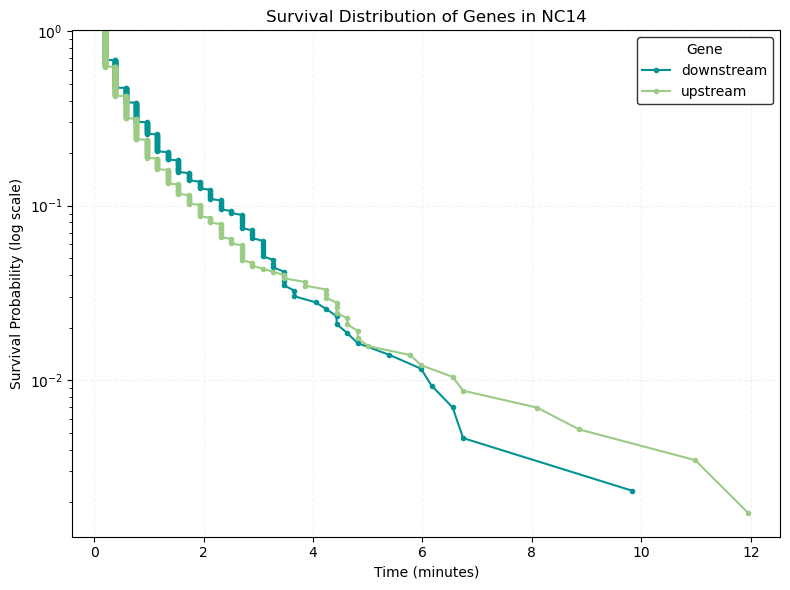

In [87]:
# survival curve

# Define the desired gene order
# genes_order = ['snail', 'hunchback_v', 'sog', 'hunchback_l']

# Loop through each nuclear cycle
for nc in durations_df_filtered['NC'].unique():
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    ax.set_facecolor('white')
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.8)

    # Filter for the current nuclear cycle
    nc_subset = durations_df_filtered[durations_df_filtered['NC'] == nc]

    for gene in genes_order:
        subset = nc_subset[nc_subset['Gene'] == gene]

        if not subset.empty:
            T = sorted(subset['Duration'].values)
            n = len(T)
            # Calculate survival probabilities (no fitting)
            survival_probs = [ (n - i) / n for i in range(n)]
            color = gene_colors[gene]

            # Plot with log scale on y-axis
            ax.plot(T, survival_probs, color=color, label=gene, marker='.',linestyle='-')

    # Add labels and title
    plt.xlabel('Time (minutes)', color='black')
    plt.ylabel('Survival Probability (log scale)', color='black')
    plt.title(f'Survival Distribution of Genes in {nc}', color='black')
    # Style the grid
    ax.grid(True, linestyle='--', alpha=0.1, color='gray')
    ax.set_yscale('log')
    plt.ylim(-0.01,1.01)
    plt.legend(title='Gene', framealpha=0.8, facecolor='white', edgecolor='black')
    plt.tight_layout()
    # figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F2'
    # plt.savefig(os.path.join(figdir, f'survivalcurve_{nc}.svg'), format='svg', dpi=300)
    plt.show()

### Total Overlap

#### box plots

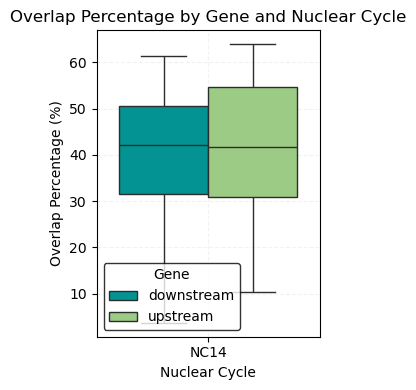

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to calculate the percentage of frames with Overlap_Pixels > 0
def calculate_overlap_percentage(df):
    overlap_percentage = []
    for label in df['Unique_Label'].unique():
        # trace = df[(df['Unique_Label'] == label) & (df['Binary_Intensity'] == 1)]
        trace = df[(df['Unique_Label'] == label)]
        # trace = df[df['Unique_Label'] == label]
        total_frames = len(trace)
        overlap_frames = (trace['Overlap_Pixels'] > 10).sum()
        percentage = (overlap_frames / total_frames) * 100
        overlap_percentage.append({
            'Filename': trace['Filename'].iloc[0],
            'Unique_Label': label,
            'Gene': trace['Gene'].iloc[0],
            'NC': trace['NC'].iloc[0],
            'Overlap_Percentage': percentage
        })
    return pd.DataFrame(overlap_percentage)

# Calculate the overlap percentage for each trace
overlap_percentage_df = calculate_overlap_percentage(merged_df)

#remove nc12
# overlap_percentage_df = overlap_percentage_df[overlap_percentage_df['NC'] != 'NC12']

# Create a boxplot to visualize the differences in durations between genes and NCs
plt.figure(figsize=(3, 4))

# Define the desired gene order
# genes_order = ['snail', 'hunchback_v', 'sog', 'hunchback_l']

sns.boxplot(x='NC', y='Overlap_Percentage', hue='Gene', data=overlap_percentage_df, palette=gene_colors, hue_order=genes_order, saturation=1.0)

# Add labels and title
plt.xlabel('Nuclear Cycle', color='black')
plt.ylabel('Overlap Percentage (%)', color='black')
plt.title('Overlap Percentage by Gene and Nuclear Cycle', color='black')
plt.legend(title='Gene', framealpha=0.8, facecolor='white', edgecolor='black')
# plt.ylim(-5,105)

#Style the axes
ax = plt.gca()
ax.set_facecolor('white')
ax.tick_params(colors='black')
ax.grid(True, linestyle='--', alpha=0.1, color='gray')
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

# Show the plot
plt.tight_layout()
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F2'
# plt.savefig(os.path.join(figdir, 'overlappercentage_boxplot_NC13_NC14.svg'), format='svg', dpi=300)
plt.show()

#### stats

In [67]:
# --- Statistical Analysis ---
def perform_stats(df, nc_group, replicate_level, measure):
    # print(f"\n--- Statistical Analysis for {nc_group}, Replicate Level: {replicate_level} ---")

    # Group data by NC and Gene
    if replicate_level == 'points':
         grouped = df.groupby(['NC','Gene'])[measure]
    elif replicate_level == 'Unique_Labels':
        grouped = df.groupby(['NC','Gene', 'Unique_Label'])[measure].mean().groupby(['NC','Gene'])
    elif replicate_level == 'Filenames':
        grouped = df.groupby(['NC','Gene', 'Filename'])[measure].mean().groupby(['NC','Gene'])
    
    results = []

    # Iterate through all pairs of groups within each NC, doing a Mann-Whitney U test
    groups = list(grouped.groups.keys())
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
                group1_name = groups[i]
                group2_name = groups[j]
                
                # Check if groups have the same NC, if not move to next iteration
                if group1_name[0] != group2_name[0]:
                    continue

                group1 = grouped.get_group(group1_name)
                group2 = grouped.get_group(group2_name)
                
                # Check if there is only one data point to remove errors
                if len(group1) < 2 or len(group2) < 2:
                    # print(f"  Skipping {group1_name} vs {group2_name} because of only one data point.")
                    continue
                
                # Perform the Mann-Whitney U tests
                u_stat_two, p_val_two = stats.mannwhitneyu(group1, group2, alternative='two-sided')
                u_stat_less, p_val_less = stats.mannwhitneyu(group1, group2, alternative='less')
                u_stat_greater, p_val_greater = stats.mannwhitneyu(group1, group2, alternative='greater')

                # Store group sizes
                n1 = len(group1)
                n2 = len(group2)
    
                # Determine significance for each test
                sig_two = 'Yes' if p_val_two < 0.05 else 'No'
                sig_less = 'Yes' if p_val_less < 0.05 else 'No'
                sig_greater = 'Yes' if p_val_greater < 0.05 else 'No'
               
                # Store result in list
                results.append({
                    'NC': nc_group,
                    'Replicate Level': replicate_level,
                    'Group 1': group1_name,
                    'Group 2': group2_name,
                    'N1': n1,
                    'N2': n2,
                    'U-statistic (two-sided)': u_stat_two,
                    'p-value (two-sided)': p_val_two,
                    'Significant (two-sided)': sig_two,
                    'U-statistic (less)': u_stat_less,
                    'p-value (less)': p_val_less,
                    'Significant (less)': sig_less,
                    'U-statistic (greater)': u_stat_greater,
                    'p-value (greater)': p_val_greater,
                    'Significant (greater)': sig_greater
                })
    return pd.DataFrame(results)

# Initialize an empty DataFrame to hold results
results_df = pd.DataFrame(columns=['NC', 'Replicate Level', 'Group 1', 'Group 2', 't-statistic', 'p-value', 'N1', 'N2', 'Significant'])

# Analysis for NC13
nc13_df = overlap_percentage_df[overlap_percentage_df['NC'] == 'NC13']
for replicate_level in ['points', 'Unique_Labels', 'Filenames']:
    results_df = pd.concat([results_df, perform_stats(nc13_df, 'NC13', replicate_level, 'Overlap_Percentage')], ignore_index=True)

# Analysis for NC14
nc14_df = overlap_percentage_df[overlap_percentage_df['NC'] == 'NC14']
for replicate_level in ['points', 'Unique_Labels', 'Filenames']:
    results_df = pd.concat([results_df, perform_stats(nc14_df, 'NC14', replicate_level, 'Overlap_Percentage')], ignore_index=True)

# # Output to CSV file
# output_csv = f'/Volumes/mirlab/S/Dorsal MS/Statistics_CSVs/stats_overlappercentage.csv'
# results_df.to_csv(output_csv, index=False)
# print(f"\nStatistical results saved to {output_csv}")

print(results_df)

     NC Replicate Level             Group 1           Group 2 t-statistic  \
0  NC14          points  (NC14, downstream)  (NC14, upstream)         NaN   
1  NC14   Unique_Labels  (NC14, downstream)  (NC14, upstream)         NaN   
2  NC14       Filenames  (NC14, downstream)  (NC14, upstream)         NaN   

  p-value  N1  N2 Significant  U-statistic (two-sided)  p-value (two-sided)  \
0     NaN  16  17         NaN                    137.5             0.971262   
1     NaN  16  17         NaN                    137.5             0.971262   
2     NaN   3   3         NaN                      5.0             1.000000   

  Significant (two-sided)  U-statistic (less)  p-value (less)  \
0                      No               137.5        0.528719   
1                      No               137.5        0.528719   
2                      No                 5.0        0.650000   

  Significant (less)  U-statistic (greater)  p-value (greater)  \
0                 No                  137.5    

## Hub & MS2 Correlation

### Random traces

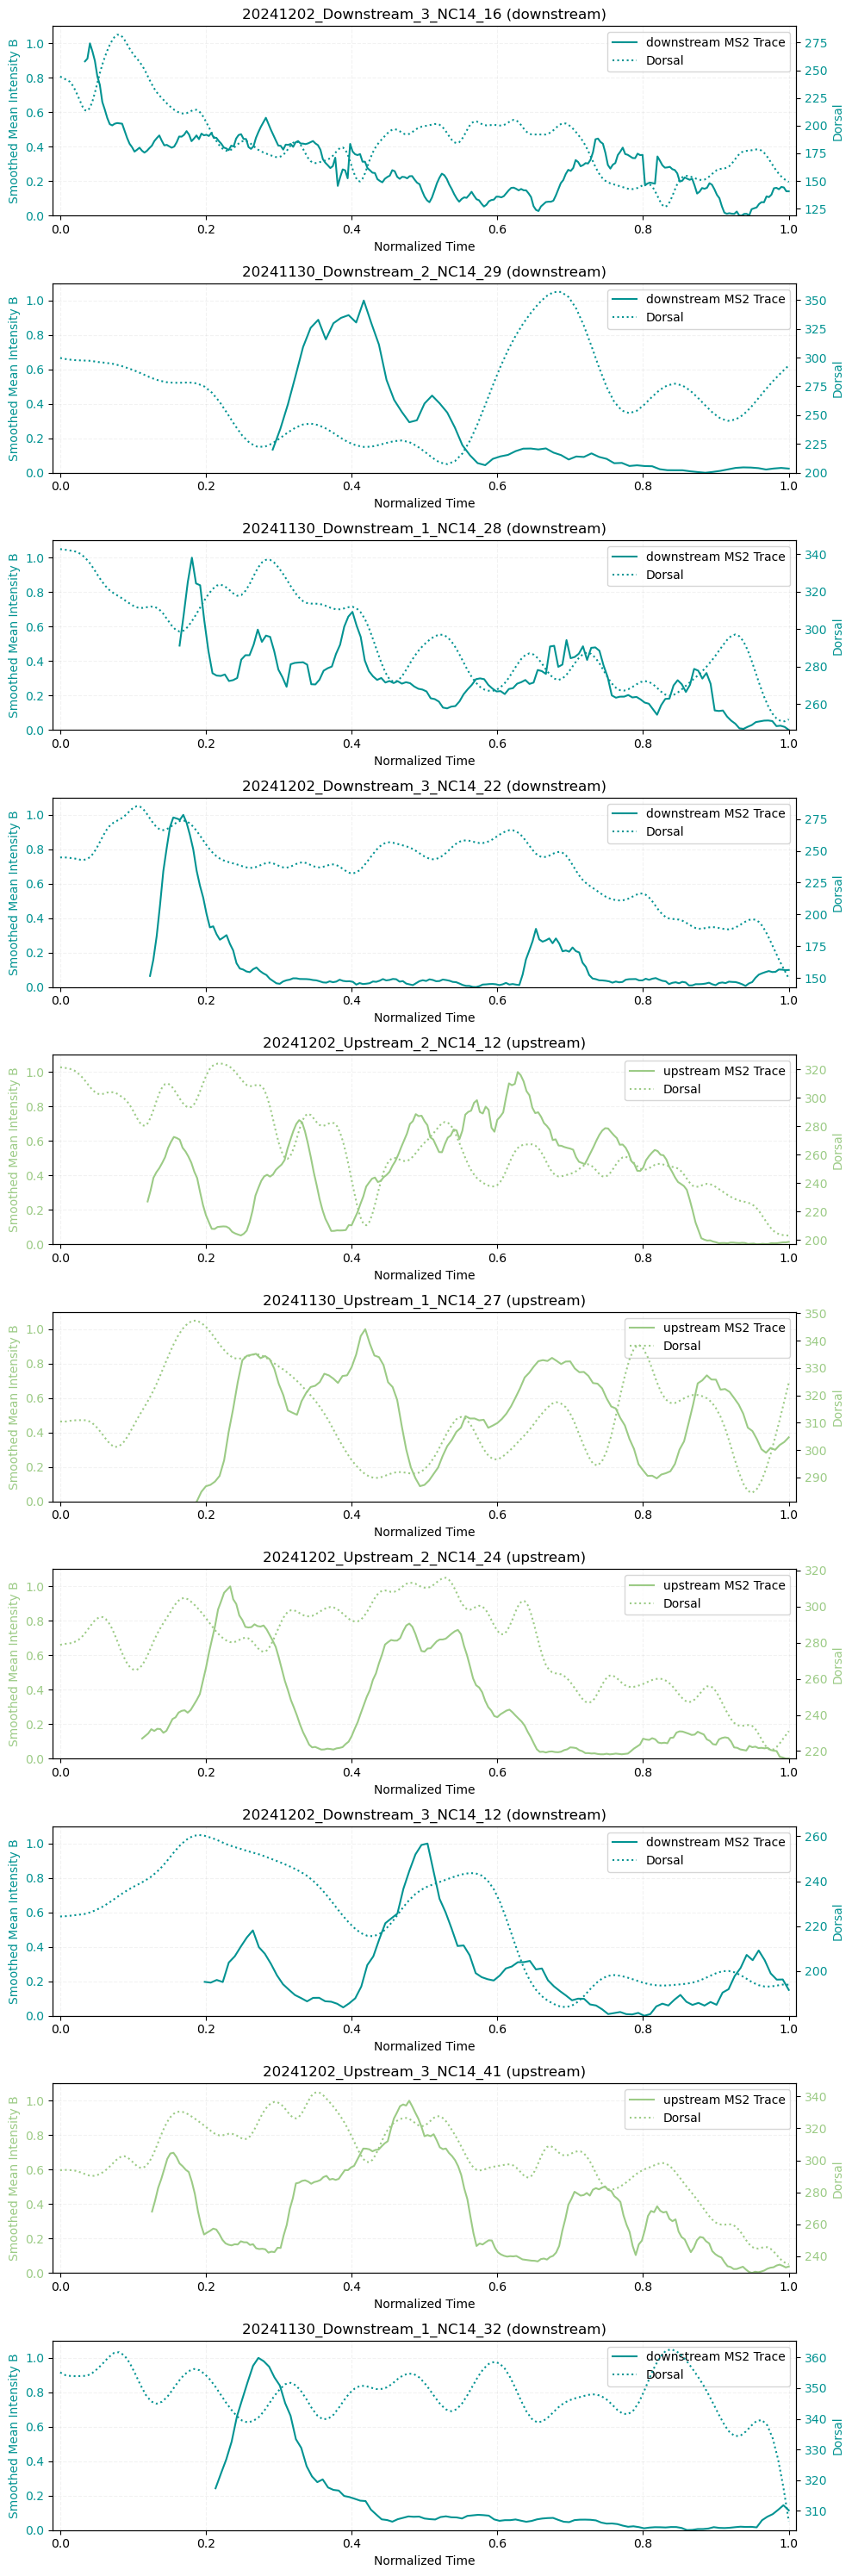

In [100]:
import random

# Define the measurements
measurements = ['Smoothed_Mean_Intensity', 'Overlap_Score_Raw', 'Overlap_Pixels']

sigma = 1

# Randomly select unique labels to plot
unique_labels_to_plot = random.sample(list(merged_df['Unique_Label'].unique()), 10)

# Create a figure
fig, axes = plt.subplots(nrows=len(unique_labels_to_plot), ncols=1, figsize=(10, 3 * len(unique_labels_to_plot)))

# Iterate through each unique label
for i, label in enumerate(unique_labels_to_plot):
    # Filter the dataframe for the current label
    trace_df = merged_df[merged_df['Unique_Label'] == label]
    
    # Get the gene associated with this label
    gene = trace_df['Gene'].iloc[0]  # Assuming the gene is consistent for a given Unique_Label

    # Smooth the data
    tracee_df = trace_df[trace_df['Frame'] >= trace_df['MS2_Start_Frame']]
    smoothed_intensity = gaussian_filter1d(tracee_df['Smoothed_Mean_Intensity_B'].values, sigma=sigma)
    smoothed_intensity = tracee_df['Smoothed_Mean_Intensity_B'].values
    # normalize smoothed_intensity
    smoothed_intensity = (smoothed_intensity - np.min(smoothed_intensity)) / (np.max(smoothed_intensity) - np.min(smoothed_intensity))

    smoothed_overlap_score = gaussian_filter1d(trace_df['Smoothed_Mean_Intensity'].values, sigma=sigma)
    smoothed_overlap_score = trace_df['Smoothed_Mean_Intensity'].values
    # smoothed_overlap_pixels = gaussian_filter1d(trace_df['Overlap_Pixels'].values, sigma=sigma)

    # Plot the measurements on a single subplot with multiple y-axes
    ax = axes[i]  # Access the correct subplot using the row index
    
    # Plot Smoothed_Mean_Intensity
    color = gene_colors[gene]
    ax.plot(tracee_df['Normalized_Time'], smoothed_intensity, color=color, label=f'{gene} MS2 Trace')
    ax.set_xlabel('Normalized Time')
    ax.set_ylabel('Smoothed Mean Intensity B', color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.set_ylim(0, 1.1)
    ax.set_xlim(-0.01, 1.01)

    # Create a second y-axis for Overlap_Score_Raw
    ax2 = ax.twinx()
    color = gene_colors[gene]
    ax2.plot(trace_df['Normalized_Time'], smoothed_overlap_score, color=color, linestyle=':', label='Dorsal')
    ax2.set_ylabel('Dorsal', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    # if gene == 'snail':
    #     ax2.set_ylim(100, 210)
    # elif gene == 'hunchback_v':
    #     ax2.set_ylim(100, 240)
    # elif gene == 'sog':
    #     ax2.set_ylim(100, 180)
    # elif gene == 'hunchback_l':
    #     ax2.set_ylim(100, 180)

    # # Create a third y-axis for Overlap_Pixels
    # ax3 = ax.twinx()
    # ax3.spines["right"].set_position(("outward", 60))  # Offset the third y-axis
    # color = 'tab:green'
    # ax3.plot(trace_df['Normalized_Time'], smoothed_overlap_pixels, color=color, linestyle=':', label='Overlap Pixels')
    # ax3.set_ylabel('Overlap Pixels', color=color)
    # ax3.tick_params(axis='y', labelcolor=color)
    
    ax.set_title(f'{label} ({gene})')
    ax.grid(True, linestyle='--', alpha=0.1, color='gray')

    # Combine legends from all axes
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    # lines3, labels3 = ax3.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc=0)

# Adjust layout
plt.tight_layout()

# # Save the figure
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F3'  # Replace with your desired directory
# if not os.path.exists(figdir):
#     os.makedirs(figdir)
# plt.savefig(os.path.join(figdir, 'combined_example_traces_MAIN.svg'), format='svg', dpi=300)

# Show the plot
plt.show()


### MCP Aligned & Dl Aligned

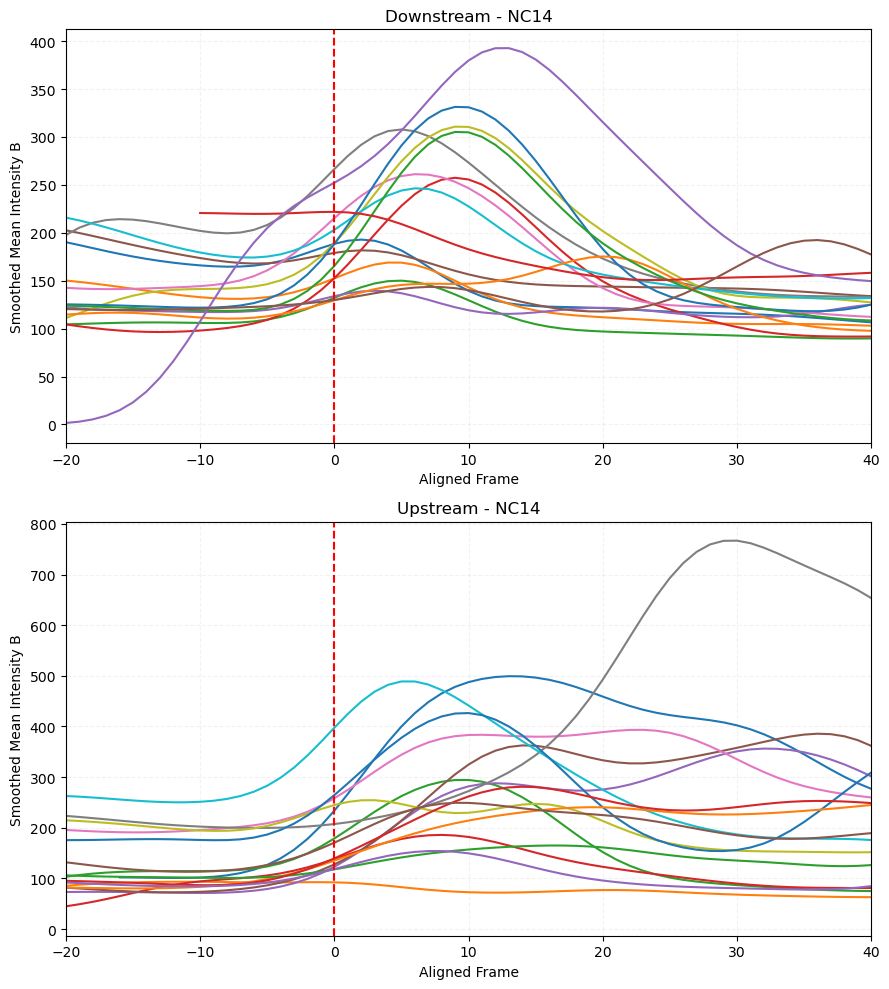

In [75]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
# Function to find the first frame where Binary_Intensity switches to 1
def find_first_binary_switch(df):
    switch_frame = df[df['Binary_Intensity'] == 1]['Frame'].min()
    return switch_frame
# Function to align traces by start_frame per nc
def align_traces_by_start_frame_per_nc(df, column, sigma=4):
    aligned_traces = []
    for nc in df['NC'].unique():
        nc_df = df[df['NC'] == nc]
        for label in nc_df['Unique_Label'].unique():
            trace = nc_df[nc_df['Unique_Label'] == label]
            smoothed_trace = gaussian_filter1d(trace[column].values, sigma=sigma)
            #normalize smoothed trace
            # smoothed_trace = (smoothed_trace - np.min(smoothed_trace)) / (np.max(smoothed_trace) - np.min(smoothed_trace))
            smoothed_traceA = gaussian_filter1d(trace['Smoothed_Mean_Intensity'].values, sigma=sigma)
            smoothed_traceA = gaussian_filter1d(smoothed_traceA, sigma=sigma)
            smoothed_overlap = gaussian_filter1d(trace['Overlap_Score_Decon'].values, sigma=sigma)
            smoothed_overlap = gaussian_filter1d(smoothed_overlap, sigma=sigma)
            # smoothed_integrated_profile = gaussian_filter1d(trace['Integrated_Profile_Decon'].values, sigma=sigma)
            # smoothed_enrichment_ratio = gaussian_filter1d(trace['Enrichment_Ratio_Decon'].values, sigma=sigma)
            smoothed_overlap_pixels = gaussian_filter1d(trace['Overlap_Pixels'].values, sigma=sigma)
            smoothed_overlap_pixels = gaussian_filter1d(smoothed_overlap_pixels, sigma=sigma)
            switch_frame = find_first_binary_switch(trace)
            
            start_frame = trace['MS2_Start_Frame'].iloc[0]
            aligned_frame = trace['Frame'] - start_frame
            aligned_traces.append(pd.DataFrame({
                'Frame': trace['Frame'],
                'Gene': trace['Gene'],
                'Aligned_Frame': aligned_frame,
                'Smoothed_Trace': smoothed_trace,
                'Smoothed_Dorsal': smoothed_traceA,
                'Overlap_Score': smoothed_overlap,
                'Overlap_Pixels': smoothed_overlap_pixels,
                'Overlap': smoothed_overlap * smoothed_overlap_pixels,
                # 'Integrated_Profile': smoothed_integrated_profile,
                # 'Enrichment_Ratio': trace['Enrichment_Ratio_Decon'],
                # 'Smoothed_Enrichment_Ratio': smoothed_enrichment_ratio,
                'NC': nc,
                'Unique_Label': label,
                'Start_Frame': start_frame,
                'Axis_Position': trace['Axis Position'],
                'Switch_Frame': switch_frame
            }))
            
    return pd.concat(aligned_traces, ignore_index=True)

# Align traces by start_frame per nc
aligned_df = align_traces_by_start_frame_per_nc(merged_df, 'Smoothed_Mean_Intensity_B')

# Filter to show only 40 frames before and after the start frame
aligned_df = aligned_df[(aligned_df['Aligned_Frame'] >= -40) & (aligned_df['Aligned_Frame'] <= 40)]

# genes = ['snail', 'hunchback_v', 'sog', 'hunchback_l']
# ncs = ['NC13', 'NC14']
# Create a figure with subplots
fig, axes = plt.subplots(nrows=len(genes), ncols=len(ncs), figsize=(9, 10))

# Iterate through each gene and NC to create the subplots
for i, gene in enumerate(genes):
    for j, nc in enumerate(ncs):
        # Filter the dataframe for the current gene and NC
        gene_nc_df = aligned_df[(aligned_df['Gene'] == gene) & (aligned_df['NC'] == nc)]
        
        # Plot the traces and start frames
        ax = axes[i]
        for label in gene_nc_df['Unique_Label'].unique():
            trace = gene_nc_df[gene_nc_df['Unique_Label'] == label]
            ax.plot(trace['Aligned_Frame'], trace['Smoothed_Trace'], label=f'Trace {label}')
        
        ax.axvline(x=0, color='red', linestyle='--', label='Start Frame')
        ax.set_title(f'{gene.capitalize()} - {nc}')
        ax.set_xlabel('Aligned Frame')
        ax.set_ylabel('Smoothed Mean Intensity B')
        ax.set_xlim(-20, 40)

        #set y lims based on gene
        if gene == 'snail':
            ax.set_ylim(0, 800)
        elif gene == 'hunchback_v':
            ax.set_ylim(0, 2000)
        elif gene == 'sog':
            ax.set_ylim(0, 3250)
        elif gene == 'hunchback_l':
            ax.set_ylim(0, 2750)



        ax.grid(True, linestyle='--', alpha=0.1, color='gray')
        # ax.legend()

# Adjust layout
plt.tight_layout()

#save figure
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F3'
# #create director if it doesn't exist
# if not os.path.exists(figdir):
#     os.makedirs(figdir)
# plt.savefig(os.path.join(figdir, f'aligned_traces.svg'), format='svg', dpi=300)

# Show the figure
plt.show()


#### average line plots

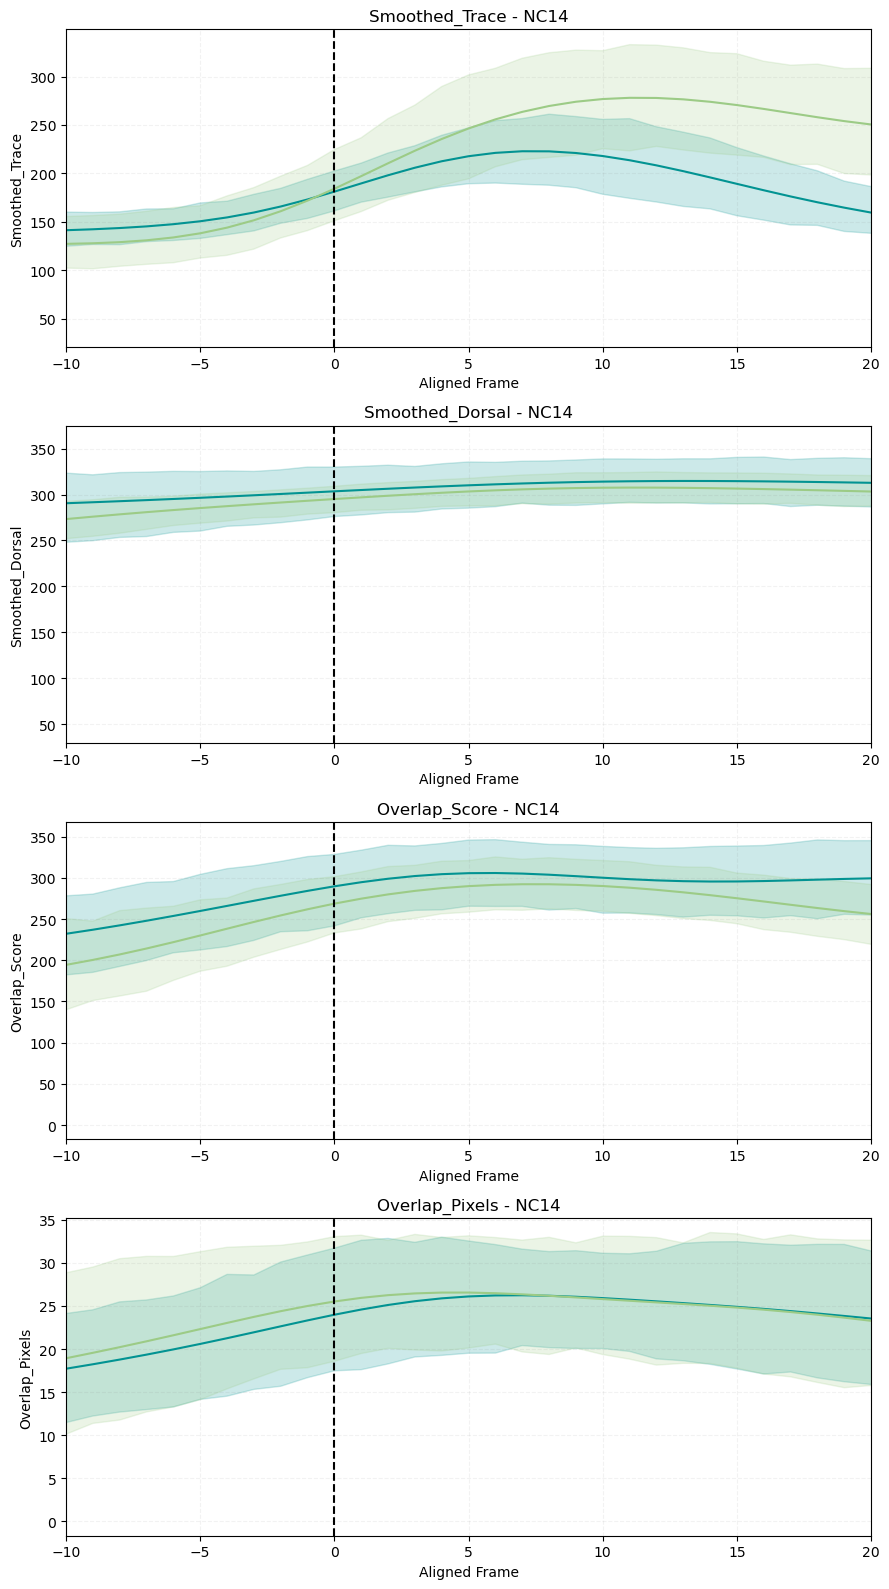

In [76]:
#line plots
import seaborn as sns
import matplotlib.pyplot as plt

measurements = ['Smoothed_Trace',
                'Smoothed_Dorsal',
                'Overlap_Score',
                'Overlap_Pixels']
                # 'Overlap']
                # 'Integrated_Profile',
                # 'Enrichment_Ratio',
                # 'Smoothed_Enrichment_Ratio']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=len(measurements), ncols=len(ncs), figsize=(9, 4 * len(measurements)))

# Iterate through each measurement and nuclear cycle (NC)
for i, measurement in enumerate(measurements):
    for j, nc in enumerate(ncs):
        # Filter the dataframe for the current NC
        nc_df = aligned_df[aligned_df['NC'] == nc]
        
        # Plot the measurement aligned to first peaks
        sns.lineplot(data=nc_df, x='Aligned_Frame', y=measurement, hue='Gene', palette=gene_colors, ax=axes[i], legend=False)

        # add vetical line at x=o
        axes[i].axvline(x=0, color='black', linestyle='--', label='Start Frame')

        axes[i].set_title(f'{measurement} - {nc}')
        axes[i].set_xlabel('Aligned Frame')
        axes[i].set_ylabel(measurement)
        axes[i].set_xlim(-10, 20)
        axes[i].grid(True, linestyle='--', alpha=0.1, color='gray')
        
        # set y lims for each measurement
        # if measurement == 'Smoothed_Trace':
        #     axes[i].set_ylim(0, 1600)
        # elif measurement == 'Smoothed_Dorsal':
        #     axes[i, j].set_ylim(0, 300)
        # elif measurement == 'Overlap_Score':
        #     axes[i, j].set_ylim(0, 350)
        # elif measurement == 'Overlap_Pixels':
        #     axes[i, j].set_ylim(0, 60)

# Adjust layout
plt.tight_layout()

#save fig
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F3'
#create director if it doesn't exist
# if not os.path.exists(figdir):
#     os.makedirs(figdir)
# plt.savefig(os.path.join(figdir, f'aligned_traces_average.svg'), format='svg', dpi=300)


# Show the plot
plt.show()


### Cross-correlation

#### Individual Heat Maps

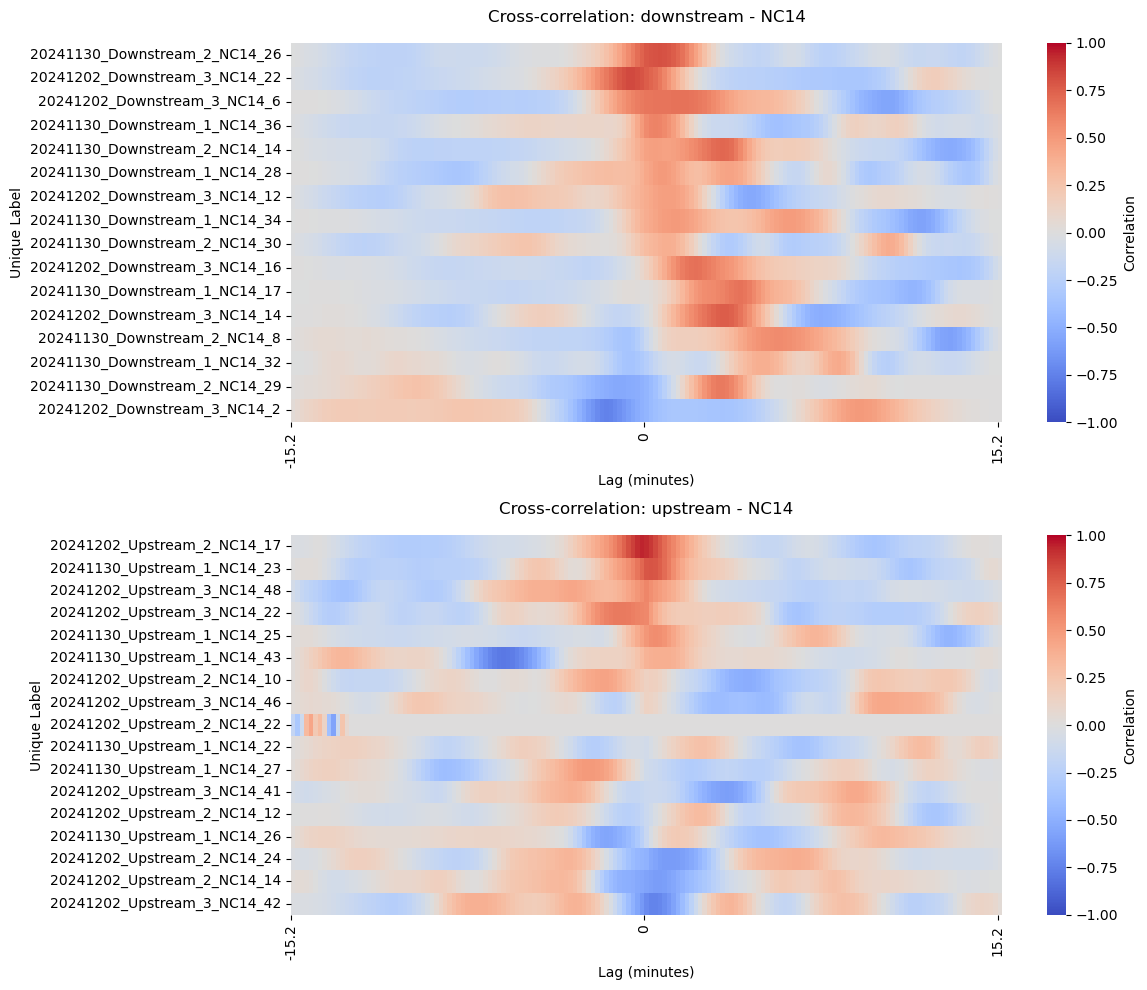

In [78]:
# Your existing functions remain the same
def normalize_trace(trace):
    min_val = np.min(trace)
    max_val = np.max(trace)
    return (trace - min_val) / (max_val - min_val)

def calculate_cross_correlation(trace1, trace2):
    return np.correlate(trace1 - np.mean(trace1), trace2 - np.mean(trace2), mode='full') / (np.std(trace1) * np.std(trace2) * len(trace1))

def pad_cross_correlations(cross_correlations):
    max_length = max(len(cross_corr) for cross_corr in cross_correlations)
    padded_cross_correlations = np.array([np.pad(cross_corr, (0, max_length - len(cross_corr)), 'constant') 
                                        for cross_corr in cross_correlations])
    return padded_cross_correlations

# Create a figure with subplots for each gene and NC
fig, axes = plt.subplots(nrows=len(genes), ncols=len(ncs), figsize=(12, 10))
# plt.style.use('dark_background')
# fig.patch.set_facecolor('black')

# Iterate through each gene and NC to create the subplots
for i, gene in enumerate(genes):
    for j, nc in enumerate(ncs):
        gene_nc_df = merged_df[(merged_df['Gene'] == gene) & (merged_df['NC'] == nc)]
        
        # Filter the dataframe for the current gene and NC
        if nc == 'NC14':
            gene_nc_df = gene_nc_df[(gene_nc_df['Frame'] < gene_nc_df['MS2_Start_Frame'] + 80) & (gene_nc_df['Frame'] >= gene_nc_df['MS2_Start_Frame'])]
        elif nc == 'NC13':
            gene_nc_df = gene_nc_df[(gene_nc_df['Frame'] < gene_nc_df['MS2_Start_Frame'] + 50) & (gene_nc_df['Frame'] >= gene_nc_df['MS2_Start_Frame'])]
        elif nc == 'NC12':
            gene_nc_df = gene_nc_df[(gene_nc_df['Frame'] < gene_nc_df['MS2_Start_Frame'] + 10) & (gene_nc_df['Frame'] >= gene_nc_df['MS2_Start_Frame'])]

        #start at start_frame
        gene_nc_df = gene_nc_df[gene_nc_df['Frame'] >= gene_nc_df['MS2_Start_Frame']]

        # Initialize lists to store cross-correlations and labels
        cross_correlations = []
        labels = []
        
        # Calculate cross-correlation for each unique label
        for label in gene_nc_df['Unique_Label'].unique():
            trace = gene_nc_df[gene_nc_df['Unique_Label'] == label]
            integrated_profile = trace['Smoothed_Mean_Intensity'].dropna().values
            overlap_score = trace['Smoothed_Mean_Intensity_B'].dropna().values
            
            # Ensure both series have the same length
            min_length = min(len(integrated_profile), len(overlap_score))
            integrated_profile = integrated_profile[:min_length]
            overlap_score = overlap_score[:min_length]
            
            # Normalize the traces
            integrated_profile = normalize_trace(integrated_profile)
            overlap_score = normalize_trace(overlap_score)
            
            # Calculate cross-correlation
            cross_corr = calculate_cross_correlation(integrated_profile, overlap_score)
            cross_correlations.append(cross_corr)
            labels.append(label)
        
        # Pad cross-correlations to the same length
        padded_cross_correlations = pad_cross_correlations(cross_correlations)
        
        # Calculate lags in minutes
        frame_rate = 11.56/60  # Assuming each frame is 0.5 minutes
        lags = np.arange(-len(padded_cross_correlations[0]) // 2 + 1, 
                        len(padded_cross_correlations[0]) // 2 + 1) * frame_rate
        
        # Create DataFrame with cross-correlations
        cross_corr_df = pd.DataFrame(padded_cross_correlations, index=labels, columns=lags)
        
        # Find lag 0 index
        lag_0_idx = np.where(lags == 0)[0][0]
        
        # Sort by correlation value at lag 0
        cross_corr_df = cross_corr_df.sort_values(by=0, ascending=False)
        
        # Plot the heatmap
        ax = axes[i]
        # ax.set_facecolor('black')
        
        sns.heatmap(cross_corr_df, 
                   cmap='coolwarm', 
                   center=0,
                   vmin=-1,  # Set minimum value to -1
                   vmax=1,   # Set maximum value to 1
                   ax=ax,
                   cbar_kws={'label': 'Correlation'})
        
        # Style the subplot
        ax.set_title(f'Cross-correlation: {gene} - {nc}',  pad=15)
        ax.set_xlabel('Lag (minutes)')
        ax.set_ylabel('Unique Label')
        
        # Style the ticks
        # ax.tick_params(colors='white')
        
        # Style the colorbar
        cbar = ax.collections[0].colorbar
        # cbar.ax.tick_params(colors='white')
        # cbar.ax.yaxis.label.set_color('white')

        # Set x-axis ticks and labels
        ax.set_xticks([0, lag_0_idx, len(lags) - 1])
        ax.set_xticklabels([round(lags[0], 1), 0, round(lags[-1], 1)])

plt.tight_layout()

#save fig
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F3'
# #create director if it doesn't exist
# if not os.path.exists(figdir):
#     os.makedirs(figdir)
# plt.savefig(os.path.join(figdir, f'cross_correlation_heatmap.png'), format='png', dpi=300)

plt.show()

#### Average Cross-Correlation

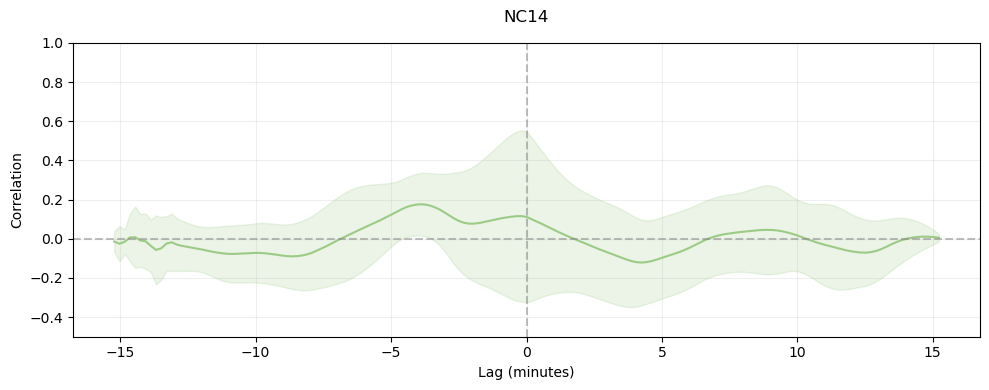

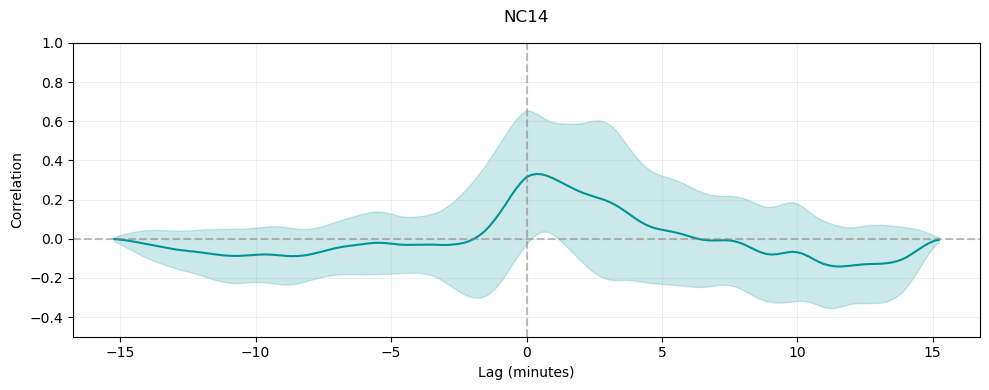

In [130]:
genes = ['upstream']

def normalize_trace(trace):
    min_val = np.min(trace)
    max_val = np.max(trace)
    return (trace - min_val) / (max_val - min_val)

def calculate_cross_correlation(trace1, trace2):
    return np.correlate(trace1 - np.mean(trace1), 
                       trace2 - np.mean(trace2), 
                       mode='full') / (np.std(trace1) * np.std(trace2) * len(trace1))

# Create figure with subplots for each NC
# plt.style.use('dark_background')
fig, axes = plt.subplots(1, len(ncs), figsize=(10, 4))
# fig.patch.set_facecolor('black')

# Process each NC
for j, nc in enumerate(ncs):
    all_correlations = {gene: [] for gene in genes}
    
    # Filter data for current NC
    nc_df = merged_df[merged_df['NC'] == nc]
    
    # Apply NC-specific filtering
    if nc == 'NC14':
        nc_df = nc_df[(nc_df['Frame'] < nc_df['MS2_Start_Frame'] + 80) & 
                      (nc_df['Frame'] >= nc_df['MS2_Start_Frame'])]
    elif nc == 'NC13':
        nc_df = nc_df[(nc_df['Frame'] < nc_df['MS2_Start_Frame'] + 50) & 
                      (nc_df['Frame'] >= nc_df['MS2_Start_Frame'])]
    elif nc == 'NC12':
        nc_df = nc_df[(nc_df['Frame'] < nc_df['MS2_Start_Frame'] + 10) & 
                      (nc_df['Frame'] >= nc_df['MS2_Start_Frame'])]

    # Calculate correlation for each trace
    for gene in genes:
        gene_nc_df = nc_df[nc_df['Gene'] == gene]
        for label in gene_nc_df['Unique_Label'].unique():
            trace = gene_nc_df[gene_nc_df['Unique_Label'] == label]
            integrated_profile = trace['Smoothed_Mean_Intensity'].dropna().values
            overlap_score = trace['Smoothed_Mean_Intensity_B'].dropna().values
            
            # Ensure same length
            min_length = min(len(integrated_profile), len(overlap_score))
            integrated_profile = integrated_profile[:min_length]
            overlap_score = overlap_score[:min_length]
            
            # Normalize and calculate correlation
            if min_length > 0:  # Only process if we have data
                integrated_profile = normalize_trace(integrated_profile)
                overlap_score = normalize_trace(overlap_score)
                cross_corr = calculate_cross_correlation(integrated_profile, overlap_score)
                all_correlations[gene].append(cross_corr)
    
    ax = axes
    # ax.set_facecolor('black')
    
    for gene in genes:
        if all_correlations[gene]:  # Only process if we have correlations
            # Pad correlations to same length
            max_length = max(len(corr) for corr in all_correlations[gene])
            padded_correlations = np.array([np.pad(corr, (0, max_length - len(corr)), 'constant') 
                                            for corr in all_correlations[gene]])
            
            # Calculate average correlation
            avg_correlation = np.mean(padded_correlations, axis=0)
            std_correlation = np.std(padded_correlations, axis=0)
            
            # Calculate lags in minutes
            frame_rate = 11.56/60  # Assuming each frame is 0.5 minutes
            lags = np.arange(-len(avg_correlation) // 2 + 1, len(avg_correlation) // 2 + 1) * frame_rate
            
            # Plot average correlation with standard deviation
            ax.plot(lags, avg_correlation, color=gene_colors[gene], label=f'{gene} - Average correlation')
            ax.fill_between(lags, 
                            avg_correlation - std_correlation,
                            avg_correlation + std_correlation,
                            color=gene_colors[gene], alpha=0.2, label=f'{gene} - ±1 std dev')
    
    # Style the plot
    ax.set_title(f'{nc}',  pad=15)
    ax.set_xlabel('Lag (minutes)')
    if j == 0:  # Only add ylabel for leftmost column
        ax.set_ylabel('Correlation')
    ax.grid(True, alpha=0.2)
    # ax.tick_params(colors='white')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    # Set y-axis limits

    ax.set_ylim(-0.5, 1)
    
    # # Add legend only for the first subplot
    # if j == 0:
    #     ax.legend(loc='upper right', framealpha=0.8, facecolor='black', edgecolor='white')

plt.tight_layout()
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F3'
# #create director if it doesn't exist
# if not os.path.exists(figdir):
#     os.makedirs(figdir)
# plt.savefig(os.path.join(figdir, f'cross_correlation_average.svg'), format='svg', dpi=300)
plt.show()

genes = ['downstream']

def normalize_trace(trace):
    min_val = np.min(trace)
    max_val = np.max(trace)
    return (trace - min_val) / (max_val - min_val)

def calculate_cross_correlation(trace1, trace2):
    return np.correlate(trace1 - np.mean(trace1), 
                       trace2 - np.mean(trace2), 
                       mode='full') / (np.std(trace1) * np.std(trace2) * len(trace1))

# Create figure with subplots for each NC
# plt.style.use('dark_background')
fig, axes = plt.subplots(1, len(ncs), figsize=(10, 4))
# fig.patch.set_facecolor('black')

# Process each NC
for j, nc in enumerate(ncs):
    all_correlations = {gene: [] for gene in genes}
    
    # Filter data for current NC
    nc_df = merged_df[merged_df['NC'] == nc]
    
    # Apply NC-specific filtering
    if nc == 'NC14':
        nc_df = nc_df[(nc_df['Frame'] < nc_df['MS2_Start_Frame'] + 80) & 
                      (nc_df['Frame'] >= nc_df['MS2_Start_Frame'])]
    elif nc == 'NC13':
        nc_df = nc_df[(nc_df['Frame'] < nc_df['MS2_Start_Frame'] + 50) & 
                      (nc_df['Frame'] >= nc_df['MS2_Start_Frame'])]
    elif nc == 'NC12':
        nc_df = nc_df[(nc_df['Frame'] < nc_df['MS2_Start_Frame'] + 10) & 
                      (nc_df['Frame'] >= nc_df['MS2_Start_Frame'])]

    # Calculate correlation for each trace
    for gene in genes:
        gene_nc_df = nc_df[nc_df['Gene'] == gene]
        for label in gene_nc_df['Unique_Label'].unique():
            trace = gene_nc_df[gene_nc_df['Unique_Label'] == label]
            integrated_profile = trace['Smoothed_Mean_Intensity'].dropna().values
            overlap_score = trace['Smoothed_Mean_Intensity_B'].dropna().values
            
            # Ensure same length
            min_length = min(len(integrated_profile), len(overlap_score))
            integrated_profile = integrated_profile[:min_length]
            overlap_score = overlap_score[:min_length]
            
            # Normalize and calculate correlation
            if min_length > 0:  # Only process if we have data
                integrated_profile = normalize_trace(integrated_profile)
                overlap_score = normalize_trace(overlap_score)
                cross_corr = calculate_cross_correlation(integrated_profile, overlap_score)
                all_correlations[gene].append(cross_corr)
    
    ax = axes
    # ax.set_facecolor('black')
    
    for gene in genes:
        if all_correlations[gene]:  # Only process if we have correlations
            # Pad correlations to same length
            max_length = max(len(corr) for corr in all_correlations[gene])
            padded_correlations = np.array([np.pad(corr, (0, max_length - len(corr)), 'constant') 
                                            for corr in all_correlations[gene]])
            
            # Calculate average correlation
            avg_correlation = np.mean(padded_correlations, axis=0)
            std_correlation = np.std(padded_correlations, axis=0)
            
            # Calculate lags in minutes
            frame_rate = 11.56/60  # Assuming each frame is 0.5 minutes
            lags = np.arange(-len(avg_correlation) // 2 + 1, len(avg_correlation) // 2 + 1) * frame_rate
            
            # Plot average correlation with standard deviation
            ax.plot(lags, avg_correlation, color=gene_colors[gene], label=f'{gene} - Average correlation')
            ax.fill_between(lags, 
                            avg_correlation - std_correlation,
                            avg_correlation + std_correlation,
                            color=gene_colors[gene], alpha=0.2, label=f'{gene} - ±1 std dev')
    
    # Style the plot
    ax.set_title(f'{nc}',  pad=15)
    ax.set_xlabel('Lag (minutes)')
    if j == 0:  # Only add ylabel for leftmost column
        ax.set_ylabel('Correlation')
    ax.grid(True, alpha=0.2)
    # ax.tick_params(colors='white')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    # Set y-axis limits

    ax.set_ylim(-0.5, 1)
    
    # # Add legend only for the first subplot
    # if j == 0:
    #     ax.legend(loc='upper right', framealpha=0.8, facecolor='black', edgecolor='white')

plt.tight_layout()
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F3'
# #create director if it doesn't exist
# if not os.path.exists(figdir):
#     os.makedirs(figdir)
# plt.savefig(os.path.join(figdir, f'cross_correlation_average.svg'), format='svg', dpi=300)
plt.show()

### Hub Overlap when above threshold

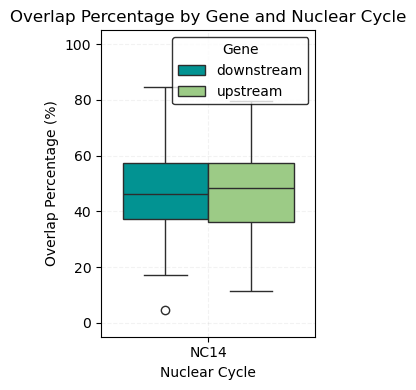

In [92]:


# Function to calculate the percentage of frames with Overlap_Pixels > 0
def calculate_overlap_percentage(df):
    overlap_percentage = []
    for label in df['Unique_Label'].unique():
        trace = df[(df['Unique_Label'] == label) & (df['Binary_Intensity'] == 1)]
        # trace = df[(df['Unique_Label'] == label)]
        # trace = df[df['Unique_Label'] == label]
        total_frames = len(trace)
        overlap_frames = (trace['Overlap_Pixels'] > 10).sum()
        percentage = (overlap_frames / total_frames) * 100
        overlap_percentage.append({
            'Filename': trace['Filename'].iloc[0],
            'Unique_Label': label,
            'Gene': trace['Gene'].iloc[0],
            'NC': trace['NC'].iloc[0],
            'Overlap_Percentage': percentage
        })
    return pd.DataFrame(overlap_percentage)

# Calculate the overlap percentage for each trace
overlap_percentage_df = calculate_overlap_percentage(merged_df)

#remove nc12
overlap_percentage_df = overlap_percentage_df[overlap_percentage_df['NC'] != 'NC12']

# Create a boxplot to visualize the differences in durations between genes and NCs
plt.figure(figsize=(3, 4))

# Define the desired gene order
# genes_order = ['snail', 'hunchback_v', 'sog', 'hunchback_l']

sns.boxplot(x='NC', y='Overlap_Percentage', hue='Gene', data=overlap_percentage_df, palette=gene_colors, hue_order=genes_order,  saturation=1)

# Add labels and title
plt.xlabel('Nuclear Cycle', color='black')
plt.ylabel('Overlap Percentage (%)', color='black')
plt.title('Overlap Percentage by Gene and Nuclear Cycle', color='black')
plt.legend(title='Gene', framealpha=0.8, facecolor='white', edgecolor='black')
plt.ylim(-5,105)

#Style the axes
ax = plt.gca()
ax.set_facecolor('white')
ax.tick_params(colors='black')
ax.grid(True, linestyle='--', alpha=0.1, color='gray')
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

# Show the plot
plt.tight_layout()
# figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F3'
# plt.savefig(os.path.join(figdir, 'overlappercentage_WHEN_ON_boxplot_NC13_NC14.svg'), format='svg', dpi=300)
plt.show()

In [131]:
# --- Statistical Analysis ---
def perform_stats(df, nc_group, replicate_level, measure):
    # print(f"\n--- Statistical Analysis for {nc_group}, Replicate Level: {replicate_level} ---")

    # Group data by NC and Gene
    if replicate_level == 'points':
         grouped = df.groupby(['NC','Gene'])[measure]
    elif replicate_level == 'Unique_Labels':
        grouped = df.groupby(['NC','Gene', 'Unique_Label'])[measure].mean().groupby(['NC','Gene'])
    elif replicate_level == 'Filenames':
        grouped = df.groupby(['NC','Gene', 'Filename'])[measure].mean().groupby(['NC','Gene'])
    
    results = []

    # Iterate through all pairs of groups within each NC, doing a Mann-Whitney U test
    groups = list(grouped.groups.keys())
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
                group1_name = groups[i]
                group2_name = groups[j]
                
                # Check if groups have the same NC, if not move to next iteration
                if group1_name[0] != group2_name[0]:
                    continue

                group1 = grouped.get_group(group1_name)
                group2 = grouped.get_group(group2_name)
                
                # Check if there is only one data point to remove errors
                if len(group1) < 2 or len(group2) < 2:
                    # print(f"  Skipping {group1_name} vs {group2_name} because of only one data point.")
                    continue
                
                # Perform the Mann-Whitney U tests
                u_stat_two, p_val_two = stats.mannwhitneyu(group1, group2, alternative='two-sided')
                u_stat_less, p_val_less = stats.mannwhitneyu(group1, group2, alternative='less')
                u_stat_greater, p_val_greater = stats.mannwhitneyu(group1, group2, alternative='greater')

                # Store group sizes
                n1 = len(group1)
                n2 = len(group2)
    
                # Determine significance for each test
                sig_two = 'Yes' if p_val_two < 0.05 else 'No'
                sig_less = 'Yes' if p_val_less < 0.05 else 'No'
                sig_greater = 'Yes' if p_val_greater < 0.05 else 'No'
               
                # Store result in list
                results.append({
                    'NC': nc_group,
                    'Replicate Level': replicate_level,
                    'Group 1': group1_name,
                    'Group 2': group2_name,
                    'N1': n1,
                    'N2': n2,
                    'U-statistic (two-sided)': u_stat_two,
                    'p-value (two-sided)': p_val_two,
                    'Significant (two-sided)': sig_two,
                    'U-statistic (less)': u_stat_less,
                    'p-value (less)': p_val_less,
                    'Significant (less)': sig_less,
                    'U-statistic (greater)': u_stat_greater,
                    'p-value (greater)': p_val_greater,
                    'Significant (greater)': sig_greater
                })
    return pd.DataFrame(results)

# Initialize an empty DataFrame to hold results
results_df = pd.DataFrame(columns=['NC', 'Replicate Level', 'Group 1', 'Group 2', 't-statistic', 'p-value', 'N1', 'N2', 'Significant'])

# Analysis for NC13
nc13_df = overlap_percentage_df[overlap_percentage_df['NC'] == 'NC13']
for replicate_level in ['points', 'Unique_Labels', 'Filenames']:
    results_df = pd.concat([results_df, perform_stats(nc13_df, 'NC13', replicate_level, 'Overlap_Percentage')], ignore_index=True)

# Analysis for NC14
nc14_df = overlap_percentage_df[overlap_percentage_df['NC'] == 'NC14']
for replicate_level in ['points', 'Unique_Labels', 'Filenames']:
    results_df = pd.concat([results_df, perform_stats(nc14_df, 'NC14', replicate_level, 'Overlap_Percentage')], ignore_index=True)

# Output to CSV file
# output_csv = f'/Volumes/mirlab/S/Dorsal MS/Statistics_CSVs/stats_overlappercentage_whenON.csv'
# results_df.to_csv(output_csv, index=False)
# print(f"\nStatistical results saved to {output_csv}")

print(results_df)

     NC Replicate Level             Group 1           Group 2 t-statistic  \
0  NC14          points  (NC14, downstream)  (NC14, upstream)         NaN   
1  NC14   Unique_Labels  (NC14, downstream)  (NC14, upstream)         NaN   
2  NC14       Filenames  (NC14, downstream)  (NC14, upstream)         NaN   

  p-value  N1  N2 Significant  U-statistic (two-sided)  p-value (two-sided)  \
0     NaN  16  17         NaN                    139.0             0.928244   
1     NaN  16  17         NaN                    139.0             0.928244   
2     NaN   3   3         NaN                      5.0             1.000000   

  Significant (two-sided)  U-statistic (less)  p-value (less)  \
0                      No               139.0        0.550164   
1                      No               139.0        0.550164   
2                      No                 5.0        0.650000   

  Significant (less)  U-statistic (greater)  p-value (greater)  \
0                 No                  139.0    

In [115]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import os  # Import the 'os' module
from scipy.signal import find_peaks
import numpy as np
import pandas as pd


# Assuming merged_df is defined elsewhere in your script

# Box Plots

# Function to calculate consecutive durations of non-zero values with a gap of at least two frames
def calculate_consecutive_durations(series):
    durations = []
    current_duration = 0
    gap = 0
    for value in series:
        if value > 0:
            if gap >= 1:
                if current_duration > 0:
                    durations.append(current_duration)
                current_duration = 1
                gap = 0
            else:
                current_duration += 1
        else:
            gap += 1
            if current_duration > 0 and gap >= 1:
                durations.append(current_duration)
                current_duration = 0
    if current_duration > 0:
        durations.append(current_duration)
    return durations

# Initialize an empty list to store the results
results = []

# Iterate through each unique label
for label in merged_df['Unique_Label'].unique():
    trace = merged_df[merged_df['Unique_Label'] == label]
    trace = trace.dropna(subset=['Overlap_Pixels'])  # Remove NaNs
    overlap_pixels = trace['Overlap_Pixels'].values  # Get the Overlap_Pixels values as a NumPy array
    overlap_score = trace['Overlap_Score_Raw'].values #Get the Overlap Score
    durations = calculate_consecutive_durations(trace['Overlap_Pixels'])

    start_frame = 0
    current_frame = 0

    for duration_frames in durations:
        # Find the start and end frame of each interaction
        interaction_start_index = np.argmax(overlap_pixels[current_frame:] > 0) + current_frame
        interaction_end_index = interaction_start_index + duration_frames

        # Calculate start and end frames, times
        interaction_start_frame = trace['Frame'].iloc[interaction_start_index]
        interaction_end_frame = trace['Frame'].iloc[interaction_end_index-1] # Corrected end frame
        interaction_start_time = trace['Normalized_Time'].iloc[interaction_start_index]
        interaction_end_time = trace['Normalized_Time'].iloc[interaction_end_index-1] # Corrected end time

        # Pull out the Data!
        interaction_pixels = overlap_pixels[interaction_start_index:interaction_end_index]
        interaction_scores = overlap_score[interaction_start_index:interaction_end_index]

        # Calculate the metrics
        max_interaction_intensity = np.max(interaction_scores)
        avg_interaction_intensity = np.mean(interaction_scores)
        max_interaction_strength = np.max(interaction_pixels)
        avg_interaction_strength = np.mean(interaction_pixels)

        results.append({
            'Filename': trace['Filename'].iloc[0],
            'Unique_Label': label,
            'Gene': trace['Gene'].iloc[0],
            'NC': trace['NC'].iloc[0],
            'Interaction_Start_Frame': interaction_start_frame,
            'Interaction_End_Frame': interaction_end_frame,
            'Interaction_Start_Time': interaction_start_time,
            'Interaction_End_Time': interaction_end_time,
            'Duration_Frames': duration_frames,  # Store the duration in frames
            'Duration_Minutes': duration_frames * 11.56 / 60,  # Convert frames to minutes
            'Max_Interaction_Intensity': max_interaction_intensity,
            'Avg_Interaction_Intensity': avg_interaction_intensity,
            'Max_Interaction_Strength': max_interaction_strength,
            'Avg_Interaction_Strength': avg_interaction_strength,
        })
        current_frame = interaction_end_index

# Create a DataFrame from the results
hub_interactions_df = pd.DataFrame(results)

# Filter durations_df to include only NC13 and NC14
hub_interactions_df_filtered = hub_interactions_df[hub_interactions_df['NC'].isin(['NC13', 'NC14'])]
# hub_interactions_df_filtered = hub_interactions_df_filtered[hub_interactions_df_filtered['Duration_Minutes'] < 20] # Use correct column


# Define the measurements
measurements = ['Smoothed_Mean_Intensity', 'Overlap_Score_Raw', 'Overlap_Pixels']

sigma = 4

# Define the genes
# genes = ['snail', 'hunchback_v', 'sog', 'hunchback_l']
# ncs = ['NC13', 'NC14']
# Get all unique labels from the merged_df
unique_labels = merged_df['Unique_Label'].unique()

all_bursts_data = []  # List to store burst data for all labels

# *******************************************************************
# NORMALIZATION
# *******************************************************************

#Normalize Smoothed Mean Intensity B, uses merged_df
for filename in merged_df['Filename'].unique():
    for nc in merged_df['NC'].unique(): #iterate through nc's
        file_nc_df = merged_df[(merged_df['Filename'] == filename) & (merged_df['NC'] == nc)].copy() # get appropriate data
        if file_nc_df['Smoothed_Mean_Intensity_B'].max() == file_nc_df['Smoothed_Mean_Intensity_B'].min(): #skip if intensity doesn't change (to avoid dividing by 0)
            merged_df.loc[(merged_df['Filename'] == filename) & (merged_df['NC'] == nc), 'Smoothed_Mean_Intensity_B_Normalized'] = 0
        else: #normalization
            merged_df.loc[(merged_df['Filename'] == filename) & (merged_df['NC'] == nc), 'Smoothed_Mean_Intensity_B_Normalized'] = (file_nc_df['Smoothed_Mean_Intensity_B'] - file_nc_df['Smoothed_Mean_Intensity_B'].min()) / (file_nc_df['Smoothed_Mean_Intensity_B'].max() - file_nc_df['Smoothed_Mean_Intensity_B'].min()) # save normalized data to new column


# for nc in ncs:
# Iterate through each unique label
for label in unique_labels:
    # Filter the dataframe for the current label
    trace_df = merged_df[merged_df['Unique_Label'] == label]
    filename = trace_df['Filename'].iloc[0]

    # Get the gene associated with this label
    gene = trace_df['Gene'].iloc[0]  # Assuming the gene is consistent for a given Unique_Label
    nc = trace_df['NC'].iloc[0]  # Assuming the NC is consistent for a given Unique_Label

    # Get the relevant normalized smoothed intensity data
    filename = trace_df['Filename'].iloc[0]
    nc = trace_df['NC'].iloc[0]
    tracee_df = trace_df[trace_df['Frame'] >= trace_df['MS2_Start_Frame']].copy()

    # # Normalize smoothed intensity for peak finding
    # smoothed_intensity_normalized = (smoothed_intensity - np.min(smoothed_intensity)) / (np.max(smoothed_intensity) - np.min(smoothed_intensity))

    # Instead of smoothing, just use pre-normalized mean intensity B
    smoothed_intensity_normalized = tracee_df['Smoothed_Mean_Intensity_B_Normalized'].values
    smoothed_intensity = tracee_df['Smoothed_Mean_Intensity_B'].values # still use smoothed data for calculations
    smoothed_intensity = gaussian_filter1d(smoothed_intensity, sigma=1) #smooth to get good derivative values

    #smooth
    smoothed_intensitys = gaussian_filter1d(smoothed_intensity_normalized, sigma=4)
    # smoothed_intensitys = smoothed_intensity

    # ********************
    # NEW BURST CALLING METHOD: RISING ACTION AS BURST
    # ********************

    # 1. Calculate the derivative
    derivative = np.diff(smoothed_intensity_normalized)
    derivative = np.insert(derivative, 0, 0)  # Pad to same length

    # 2. Find rising action indices (where derivative > 0)
    rising_indices = np.where(derivative > 0)[0]

    # 3. Group consecutive rising indices into bursts.
    #    Each burst consists of a start index and a peak index (end of rising action)
    burst_starts = []
    burst_ends = []
    if len(rising_indices) > 0:
        burst_starts.append(rising_indices[0])  # First rising index starts a burst
        for i in range(1, len(rising_indices)):
            if rising_indices[i] != rising_indices[i-1] + 1:  # Not consecutive
                burst_ends.append(rising_indices[i-1])      # End previous burst
                burst_starts.append(rising_indices[i])      # Start new burst
        burst_ends.append(rising_indices[-1]) #Last burst to append

    # Assign new burst start and ends
    merged_burst_starts = burst_starts
    merged_burst_ends = burst_ends

    # Calculate Time
    normalized_time = tracee_df['Normalized_Time'].values

    # ********************************************************
    # Calculate Burst Threshold, using value from merged_df
    # ********************************************************
    Burst_Threshold = trace_df['Burst_Threshold'].iloc[0]  # Get Burst_Threshold from trace_df
    # Total number of frames where intensity is above the threshold
    above_threshold_frames = np.sum(smoothed_intensity > Burst_Threshold)
    # Total number of frames
    max_frames = len(smoothed_intensity)
    # Calculate the duty cycle
    Duty_Cycle = above_threshold_frames / max_frames if max_frames > 0 else np.nan

    # Collect burst data
    for burst_idx, (start_index, end_index) in enumerate(zip(merged_burst_starts, merged_burst_ends)):

        # Calculate Relative Height
        relative_height = smoothed_intensity_normalized[end_index] - smoothed_intensity_normalized[start_index]

        # Filter out peaks with relative height less than 0.05
        if relative_height < 0.05:
            continue

        # Correctly calculate start and end frames from indices in tracee_df
        start_frame = tracee_df['Frame'].iloc[start_index]
        end_frame = tracee_df['Frame'].iloc[end_index]  #  Use end_index, not end_index - 1

        # Correct the peak
        peaks, _ = find_peaks(smoothed_intensitys[start_index:end_index], height=0.1, distance=3)  # Adjust height and distance as needed

        # Calculate Amplitude (max intensity within the burst)
        #Amplitude calculation should use the original scale
        amplitude = np.max(tracee_df['Smoothed_Mean_Intensity_B_Normalized'].values[start_index:end_index+1]) #Include the end index when finding the max
        amplitude_R = np.max(tracee_df['Smoothed_Mean_Intensity_B_Normalized'].values[start_index:end_index+1])/tracee_df['Smoothed_Mean_Intensity_B_Normalized'].values[start_index] #Include end when calculating amplitude

        # Peak frame and peak time
        if len(peaks) > 0: #If there is a peak within the rising period
            #Peak is offset from the original list of frames.
            peak_frame = tracee_df['Frame'].iloc[start_index + peaks[0]]
            peak_time = tracee_df['Normalized_Time'].iloc[start_index + peaks[0]]
        else: #If there is no peak then burst starts and ends at the same time.
            peak_frame = tracee_df['Frame'].iloc[start_index]
            peak_time = tracee_df['Normalized_Time'].iloc[start_index]

        # Duration (in frames)
        duration = end_frame - start_frame

        # Output (integrated intensity within the burst - approximation using sum)
        output = np.sum(tracee_df['Smoothed_Mean_Intensity_B_Normalized'].values[start_index:end_index+1]) # include the endpoints

        # Initialize hub measurement dictionaries
        hub_averages = {}  # Changed name to reflect the correct calculation
        pre_burst_values = {}
        pre_burst_values_avg = {}
        pre_burst_values_sum = {}
        post_burst_values = {}
        time_shifts = {}

        # Calculate Hub Measurements
        for hub_metric in measurements:
            # Get hub metric values from tracee_df sorted by frame
            sorted_tracee_df = tracee_df.sort_values('Frame')
            hub_metric_values = sorted_tracee_df[hub_metric].values

            # Average Hub Metric DURING the burst
            #find mid poitn of burst
            mid_point = int((start_index + end_index) / 2) 
            # print(start_index, peak_frame, end_index)
            # mid_point = min(len(tracee_df), peak_frame) - 1
            hub_averages[f'{hub_metric}_during'] = np.mean(hub_metric_values[mid_point])

            # Before the burst (average of 5 frames before)
            pre_burst_start = max(0, start_index - 2)
            pre_burst_values[f'{hub_metric}_pre'] = np.mean(hub_metric_values[pre_burst_start])

            # Before the burst (average of 5 frames before)
            pre_burst_start = max(0, start_index)
            #take average of up to 5 frames before start_index
            pre_burst_start_minus_5 = max(0, start_index - 3)
            if pre_burst_start_minus_5 == pre_burst_start:
                pre_burst_values_avg[f'{hub_metric}_pre'] = np.nanmean(hub_metric_values[pre_burst_start])
                pre_burst_values_sum[f'{hub_metric}_pre'] = np.nanmean(hub_metric_values[pre_burst_start])
            pre_burst_values_avg[f'{hub_metric}_pre_avg'] = np.nanmean(hub_metric_values[pre_burst_start_minus_5:pre_burst_start])
            pre_burst_values_sum[f'{hub_metric}_pre_sum'] = np.nansum(hub_metric_values[pre_burst_start_minus_5:pre_burst_start])

            # After the burst (average of 5 frames after)
            post_burst_end = min(len(tracee_df), end_index + 2) - 1
            post_burst_values[f'{hub_metric}_post'] = np.mean(hub_metric_values[post_burst_end])

            # Time shift of peak BEFORE burst
            before_burst = hub_metric_values[:start_index]  # Hub metric before the start of the burst
            if len(before_burst) > 0:
                peak_index = np.argmax(before_burst)
                time_shifts[f'{hub_metric}_timeshift'] = tracee_df['Normalized_Time'].iloc[start_index] - tracee_df['Normalized_Time'].iloc[peak_index]
            else:
                time_shifts[f'{hub_metric}_timeshift'] = np.nan  # Handle case where there are no frames before the burst

        # Find overlapping hub interaction
        burst_start_time = tracee_df['Normalized_Time'].iloc[start_index]
        burst_end_time = tracee_df['Normalized_Time'].iloc[end_index]

        overlapping_interaction = hub_interactions_df[
            (hub_interactions_df['Unique_Label'] == label) &
            (hub_interactions_df['Interaction_Start_Time'] <= burst_end_time) &
            (hub_interactions_df['Interaction_End_Time'] >= burst_start_time)
        ]

        # Get time differences and hub data if the overlapping_interaction is not empty
        if not overlapping_interaction.empty:
            interaction_start_time = overlapping_interaction['Interaction_Start_Time'].iloc[0]
            interaction_end_time = overlapping_interaction['Interaction_End_Time'].iloc[0]

            hub_arrival_time_relative_to_burst_start = interaction_start_time - burst_start_time
            hub_arrival_time_relative_to_burst_start_frame = overlapping_interaction['Interaction_Start_Frame'].iloc[0] - start_frame
            hub_interaction_duration_after_burst_start = interaction_end_time - burst_start_time
            hub_interaction_duration_after_burst_start_frame = overlapping_interaction['Interaction_End_Frame'].iloc[0] - start_frame

            max_interaction_intensity = overlapping_interaction['Max_Interaction_Intensity'].iloc[0]
            avg_interaction_intensity = overlapping_interaction['Avg_Interaction_Intensity'].iloc[0]
            max_interaction_strength = overlapping_interaction['Max_Interaction_Strength'].iloc[0]
            avg_interaction_strength = overlapping_interaction['Avg_Interaction_Strength'].iloc[0]

        else:
            hub_arrival_time_relative_to_burst_start = np.nan
            hub_interaction_duration_after_burst_start = np.nan
            hub_arrival_time_relative_to_burst_start_frame = np.nan
            hub_interaction_duration_after_burst_start_frame = np.nan
            max_interaction_intensity = np.nan
            avg_interaction_intensity = np.nan
            max_interaction_strength = np.nan
            avg_interaction_strength = np.nan

        # Store burst data
        all_bursts_data.append({
            'Filename': filename,
            'Unique_Label': label,
            'NC': nc,
            'Start_Frame': start_frame,
            'End_Frame': end_frame,
            'Start_Time': tracee_df['Normalized_Time'].iloc[start_index],
            'End_Time': tracee_df['Normalized_Time'].iloc[end_index], # No minus 1 here
            'Amplitude': amplitude,
            'Amplitude_R': amplitude_R,
            'Duration': duration,
            'Output': output,
            'Frequency': None,  # Placeholder, will be calculated later
            'Is_First_Burst': burst_idx == 0,
            'Gene': gene,
            'Peak_Frame': peak_frame,
            'Peak_Time': peak_time,
            **hub_averages,  # Use the correct name here
            **pre_burst_values,
            **pre_burst_values_avg,
            **pre_burst_values_sum,
            **post_burst_values,
            **time_shifts,
            'Hub_Arrival_Time_Relative_To_Burst_Start': hub_arrival_time_relative_to_burst_start,
            'Hub_Arrival_Time_Relative_To_Burst_Start_Frame': hub_arrival_time_relative_to_burst_start_frame *(6.736/60),
            'Hub_Arrival_Time_Relative_To_Burst_Start_Min': hub_arrival_time_relative_to_burst_start_frame,
            'Hub_Interaction_Duration_After_Burst_Start': hub_interaction_duration_after_burst_start,
            'Hub_Interaction_Duration_After_Burst_Start_Frame': hub_interaction_duration_after_burst_start_frame,
            'Hub_Interaction_Duration_After_Burst_Start_Min': hub_interaction_duration_after_burst_start_frame *(6.736/60),
            'Max_Interaction_Intensity': max_interaction_intensity,
            'Avg_Interaction_Intensity': avg_interaction_intensity,
            'Max_Interaction_Strength': max_interaction_strength,
            'Avg_Interaction_Strength': avg_interaction_strength,
            # Duty Cycle, PulseWidth and Time Between Bursts (all in units of frames)
            'Duty_Cycle': None,
            'Pulse_Width': duration,
            'Time_Between_Bursts': None,
})

# Create the all_bursts_df from the collected data
all_bursts_df = pd.DataFrame(all_bursts_data)

# ****************************************************
# Calculate Frequency and Time Between Bursts
# (These will be in units of "Frames")
# ****************************************************

# For each Unique Label
for unique_label in all_bursts_df['Unique_Label'].unique():
    label_bursts = all_bursts_df[all_bursts_df['Unique_Label'] == unique_label].sort_values('Start_Frame') #Sort to avoid errors in time calculation

    # Find time between peaks
    peak_times = label_bursts['Peak_Time'].values

    # time_between_peaks = np.diff(peak_times) # get time between neighboring peaks
    time_between_peaks = np.diff(peak_times)

    # Handle Time_Between_Bursts for the first burst: Set to Time from 0 to Peak
    if len(label_bursts) > 0: # Make sure there is data
        first_peak_time = label_bursts['Peak_Time'].iloc[0]
        all_bursts_df.loc[label_bursts.index[0], 'Time_Between_Bursts'] = first_peak_time
        all_bursts_df.loc[label_bursts.index[0], 'Frequency'] = 1/first_peak_time if first_peak_time != 0 else np.nan #Since there isn't a time to calculate with, set frequency as none

    # Check if time_between_peaks is empty
    if len(time_between_peaks) > 0:
        all_bursts_df.loc[label_bursts.index[1:], 'Time_Between_Bursts'] = time_between_peaks  # Assign times to the corresponding bursts
        all_bursts_df.loc[label_bursts.index[1:], 'Frequency'] = 1 / time_between_peaks
    else:
        # Handle the case where there is only one or zero bursts for the label
        # Assign NaN or some other appropriate value
        if len(label_bursts) > 1:
            all_bursts_df.loc[label_bursts.index[1:], 'Time_Between_Bursts'] = np.nan
            all_bursts_df.loc[label_bursts.index[1:], 'Frequency'] = np.nan
            

# ****************************************************
# Calculate Duty Cycle ##TODO: check this calculation
# ****************************************************

all_bursts_df['Duty_Cycle'] = all_bursts_df['Pulse_Width'] / all_bursts_df['Time_Between_Bursts']

# remove NC12
all_bursts_df = all_bursts_df[all_bursts_df['NC'] != 'NC12']

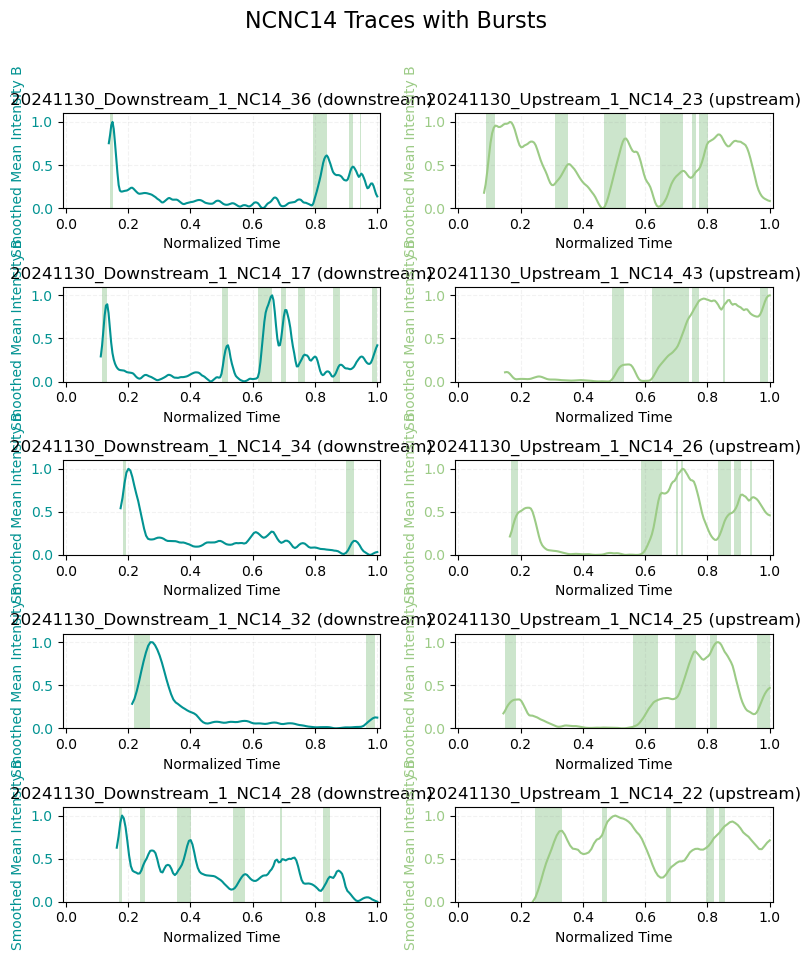

In [108]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, argrelextrema

# Assuming merged_df and gene_colors are defined elsewhere in your script

# Define the measurements
measurements = ['Smoothed_Mean_Intensity', 'Overlap_Score_Raw', 'Overlap_Pixels']

sigma = 1

# Define the genes
# genes = ['snail', 'hunchback_v', 'sog', 'hunchback_l']

# Define the NC values to plot
NC_values = [14]
NC_values = ["NC14"]

def plot_bursts(merged_df, all_bursts_df, gene_colors, NC_values, sigma=4):
    """Plots bursts from all_bursts_df on traces from merged_df using vertical lines."""

    for nc in NC_values:
        # Create a figure for the current NC
        fig, axes = plt.subplots(nrows=5, ncols=len(genes), figsize=(4 * len(genes), 10))
        fig.suptitle(f'NC{nc} Traces with Bursts', fontsize=16)

        # Filter all_bursts_df for the current NC
        nc_bursts_df = all_bursts_df[all_bursts_df['Unique_Label'].str.contains(nc, case=False)]

        # Iterate through genes
        for col, gene in enumerate(genes):
            # Filter merged_df for the current gene
            gene_df = merged_df[merged_df['Gene'] == gene]
            gene_df = gene_df[gene_df['Unique_Label'].str.contains(nc, case=False)]

            # Get unique labels for the current gene
            unique_labels = gene_df['Unique_Label'].unique()

            # Iterate through rows (traces), up to a maximum of 5
            for row in range(min(5, len(unique_labels))):
                ax = axes[row, col]  # Access the correct subplot

                # Get the unique label for the current row
                label = unique_labels[row]

                # Filter the dataframe for the current label
                trace_df = gene_df[gene_df['Unique_Label'] == label]

                # Plotting
                color = gene_colors[gene]
                ax.set_xlabel('Normalized Time')
                ax.set_ylabel('Smoothed Mean Intensity B', color=color)
                ax.tick_params(axis='y', labelcolor=color)
                ax.set_ylim(0, 1.1)
                ax.set_xlim(-0.01, 1.01)

                try:
                    tracee_df = trace_df[trace_df['Frame'] >= trace_df['MS2_Start_Frame']]
                    smoothed_intensity = tracee_df['Smoothed_Mean_Intensity_B'].values
                    smoothed_intensity = gaussian_filter1d(smoothed_intensity, sigma=sigma)

                    # Normalize smoothed intensity
                    smoothed_intensity = (smoothed_intensity - np.min(smoothed_intensity)) / (np.max(smoothed_intensity) - np.min(smoothed_intensity))

                    # Plot the MS2 trace
                    ax.plot(tracee_df['Normalized_Time'], smoothed_intensity, color=color, label=f'{gene} MS2 Trace')

                    # Plot vertical lines for burst boundaries
                    # bursts_for_trace = nc_bursts_df[nc_bursts_df['Unique_Label'] == label]
                    # if not bursts_for_trace.empty:
                    #     for _, burst in bursts_for_trace.iterrows():
                    #         start_time = burst['Start_Time']
                    #         end_time = burst['End_Time']
                    #         # print(start_time)

                    #         if not np.isnan(start_time):
                    #             ax.axvline(x=start_time, color='green', linestyle=':', alpha=0.7, label='Start_Time' if _ == 0 else "")
                    #         if not np.isnan(end_time):
                    #             ax.axvline(x=end_time, color='purple', linestyle=':', alpha=0.7, label='End_Time' if _ == 0 else "")
                    
                    # Plot burst regions by highlighting the background when the burst is "on"
                    bursts_for_trace = nc_bursts_df[nc_bursts_df['Unique_Label'] == label]
                    if not bursts_for_trace.empty:
                        for _, burst in bursts_for_trace.iterrows():
                            start_time = burst['Start_Time']
                            end_time = burst['End_Time']

                            # Convert time to index
                            start_index = (tracee_df['Normalized_Time'] - start_time).abs().idxmin()
                            end_index = (tracee_df['Normalized_Time'] - end_time).abs().idxmin()

                            # Ensure indices are valid
                            start_index = tracee_df.index.get_loc(start_index)
                            end_index = tracee_df.index.get_loc(end_index)

                            # Check for valid indices before plotting, also make sure the indexes are correct.
                            if (0 <= start_index < len(tracee_df)) and (0 <= end_index < len(tracee_df)) and (start_index <= end_index):
                                ax.axvspan(tracee_df['Normalized_Time'].iloc[start_index], tracee_df['Normalized_Time'].iloc[end_index], facecolor='green', alpha=0.2, ymin=0, ymax=1, transform=ax.get_xaxis_transform())
                            else:
                                print(f"Invalid burst indices for label: {label}, start_index: {start_index}, end_index: {end_index}, len(tracee_df): {len(tracee_df)}")

                    ax.set_title(f'{label} ({gene})')
                    ax.grid(True, linestyle='--', alpha=0.1, color='gray')

                except Exception as e:
                    print(f"Error plotting {label}: {e}")
                    continue

        # Adjust layout and save the figure
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


# Finally, call the plotting function:
plot_bursts(merged_df, all_bursts_df, gene_colors, NC_values, sigma)

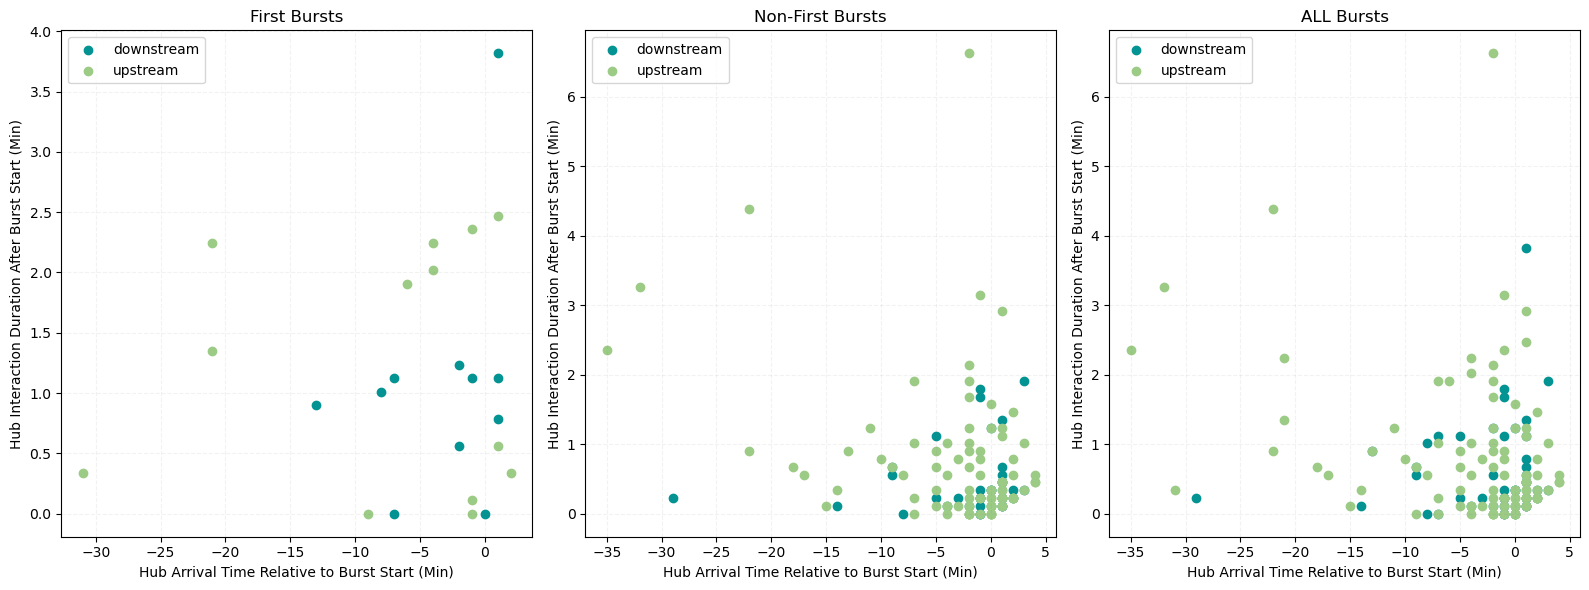

/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/3079161038.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/3079161038.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/3079161038.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gene', y='Hub_Arrival_Time_Relative_T

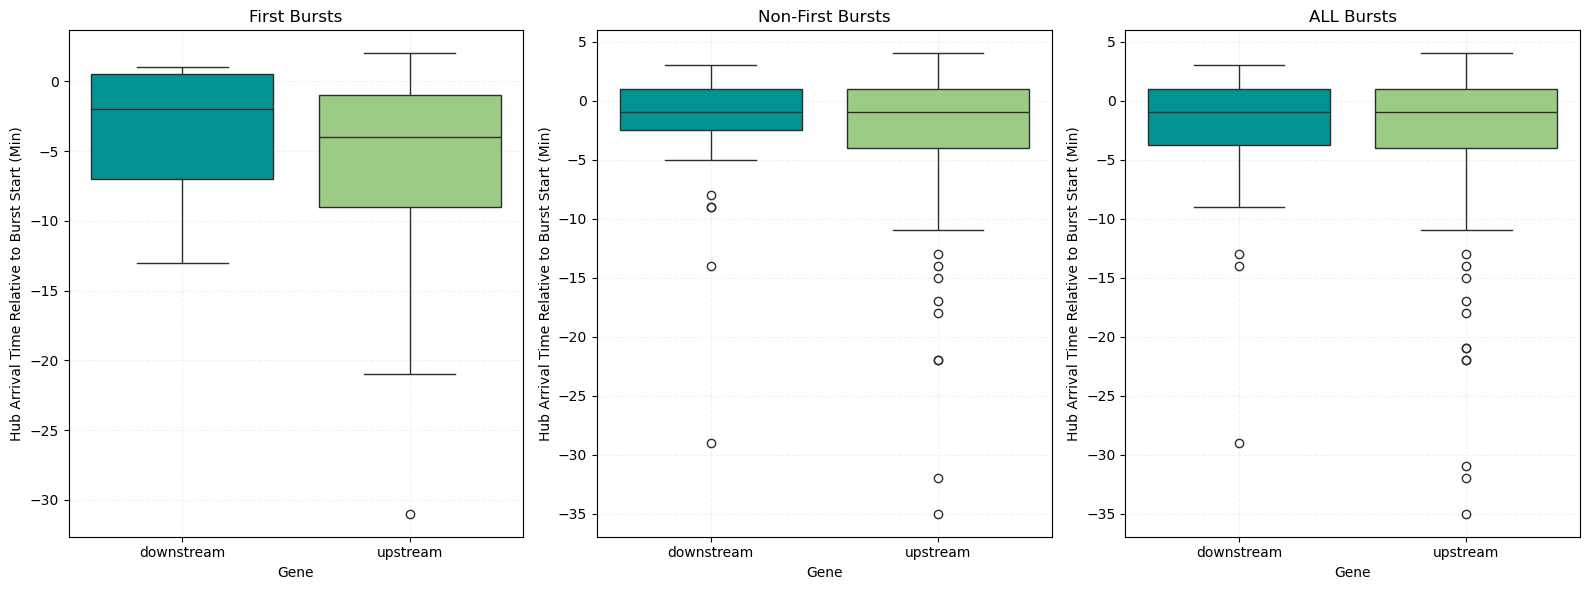

/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/3079161038.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/3079161038.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/3079161038.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gene', y='Hub_Interaction_Durat

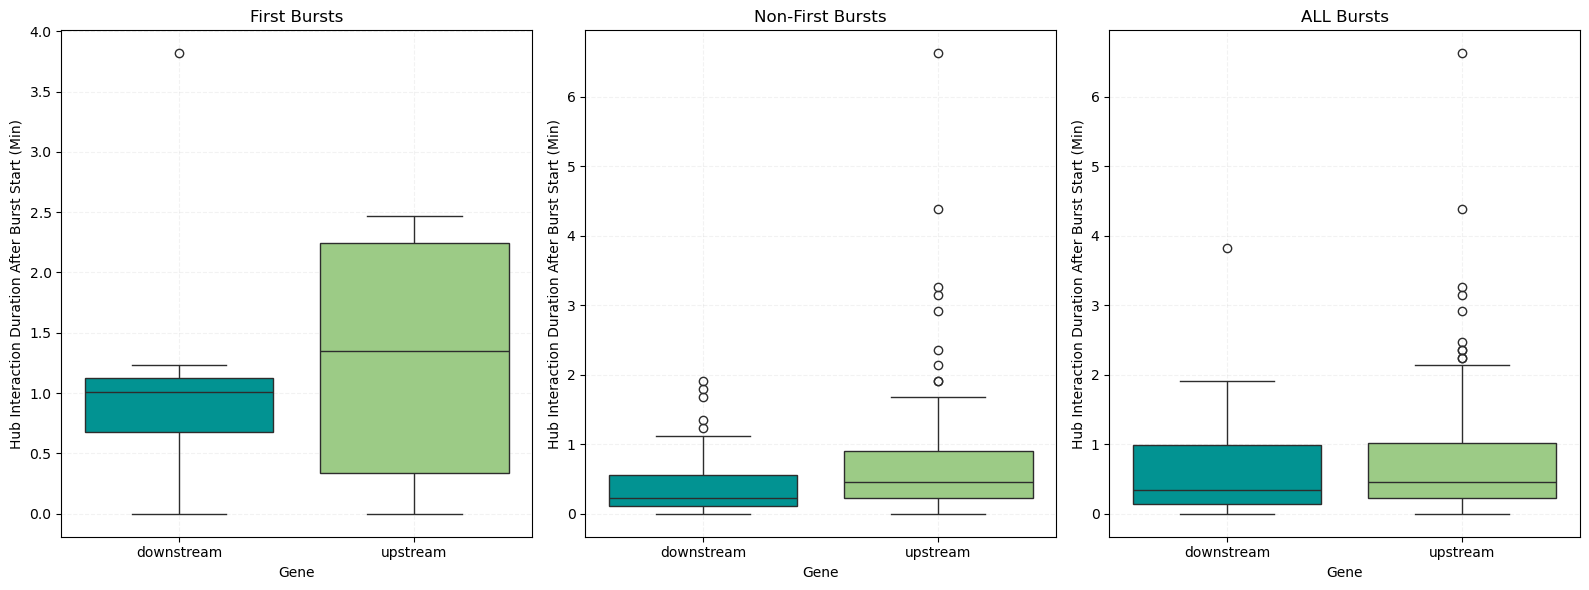

In [111]:
# Filter NC14
# all_bursts_dff = all_bursts_df[all_bursts_df['NC'] == 'NC14']
all_bursts_dff = all_bursts_df.copy()

# Create subplots for first bursts and non-first bursts
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot for first bursts
first_bursts = all_bursts_dff[all_bursts_dff['Is_First_Burst'] == True]
axes[0].set_title('First Bursts')
for gene in genes:
    subset = first_bursts[first_bursts['Gene'] == gene]
    axes[0].scatter(subset['Hub_Arrival_Time_Relative_To_Burst_Start_Min'],
                    subset['Hub_Interaction_Duration_After_Burst_Start_Min'],
                    label=gene, alpha=1.0, color=gene_colors[gene])
axes[0].set_xlabel('Hub Arrival Time Relative to Burst Start (Min)')
axes[0].set_ylabel('Hub Interaction Duration After Burst Start (Min)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.1, color='gray')

# Plot for non-first bursts
non_first_bursts = all_bursts_dff[all_bursts_dff['Is_First_Burst'] == False]
axes[1].set_title('Non-First Bursts')
for gene in genes:
    subset = non_first_bursts[non_first_bursts['Gene'] == gene]
    axes[1].scatter(subset['Hub_Arrival_Time_Relative_To_Burst_Start_Min'],
                    subset['Hub_Interaction_Duration_After_Burst_Start_Min'],
                    label=gene, alpha=1.0, color=gene_colors[gene])
axes[1].set_xlabel('Hub Arrival Time Relative to Burst Start (Min)')
axes[1].set_ylabel('Hub Interaction Duration After Burst Start (Min)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.1, color='gray')

# Plot for non-first bursts
alll_bursts = all_bursts_dff.copy()
axes[2].set_title('ALL Bursts')
for gene in genes:
    subset = alll_bursts[alll_bursts['Gene'] == gene]
    axes[2].scatter(subset['Hub_Arrival_Time_Relative_To_Burst_Start_Min'],
                    subset['Hub_Interaction_Duration_After_Burst_Start_Min'],
                    label=gene, alpha=1.0, color=gene_colors[gene])
axes[2].set_xlabel('Hub Arrival Time Relative to Burst Start (Min)')
axes[2].set_ylabel('Hub Interaction Duration After Burst Start (Min)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.1, color='gray')

plt.tight_layout()
# save fig 
figdir = '/Volumes/mirlab/S/Dorsal MS/PythonFigureOutput/F4'
#create director if it doesn't exist
if not os.path.exists(figdir):
    os.makedirs(figdir)
# plt.savefig(os.path.join(figdir, f'Hub_Arrival_vs_Interaction_Duration_Frame.svg'), format='svg', dpi=300)
plt.show()

# Box Plots of Hub Arrival Time
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot for first bursts
axes[0].set_title('First Bursts')
sns.boxplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
            data=first_bursts, order=genes, palette=gene_colors, saturation=1, ax=axes[0])
axes[0].set_xlabel('Gene')
axes[0].set_ylabel('Hub Arrival Time Relative to Burst Start (Min)')
axes[0].grid(True, linestyle='--', alpha=0.1, color='gray')

# Plot for non-first bursts
axes[1].set_title('Non-First Bursts')
sns.boxplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
            data=non_first_bursts, order=genes, palette=gene_colors, saturation=1, ax=axes[1])
axes[1].set_xlabel('Gene')
axes[1].set_ylabel('Hub Arrival Time Relative to Burst Start (Min)')
axes[1].grid(True, linestyle='--', alpha=0.1, color='gray')

# Plot for non-first bursts
axes[2].set_title('ALL Bursts')
sns.boxplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
            data=alll_bursts, order=genes, palette=gene_colors, saturation=1, ax=axes[2])
axes[2].set_xlabel('Gene')
axes[2].set_ylabel('Hub Arrival Time Relative to Burst Start (Min)')
axes[2].grid(True, linestyle='--', alpha=0.1, color='gray')


plt.tight_layout()
# plt.savefig(os.path.join(figdir, f'Hub_Arrival_BOX.svg'), format='svg', dpi=300)
plt.show()

# Box Plots of Interaction Duration
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot for first bursts
axes[0].set_title('First Bursts')
sns.boxplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
            data=first_bursts, order=genes, palette=gene_colors, saturation=1, ax=axes[0])
axes[0].set_xlabel('Gene')
axes[0].set_ylabel('Hub Interaction Duration After Burst Start (Min)')
axes[0].grid(True, linestyle='--', alpha=0.1, color='gray')

# Plot for non-first bursts
axes[1].set_title('Non-First Bursts')
sns.boxplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
            data=non_first_bursts, order=genes, palette=gene_colors, saturation=1, ax=axes[1])
axes[1].set_xlabel('Gene')
axes[1].set_ylabel('Hub Interaction Duration After Burst Start (Min)')
axes[1].grid(True, linestyle='--', alpha=0.1, color='gray')

# Plot for non-first bursts
axes[2].set_title('ALL Bursts')
sns.boxplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
            data=alll_bursts, order=genes, palette=gene_colors, saturation=1, ax=axes[2])
axes[2].set_xlabel('Gene')
axes[2].set_ylabel('Hub Interaction Duration After Burst Start (Min)')
axes[2].grid(True, linestyle='--', alpha=0.1, color='gray')

plt.tight_layout()
# plt.savefig(os.path.join(figdir, f'Hub_Duration_BOX.svg'), format='svg', dpi=300)
plt.show()

/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/1744209425.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/1744209425.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/1744209425.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Gene', y='Hub_Arrival_Time_Rela

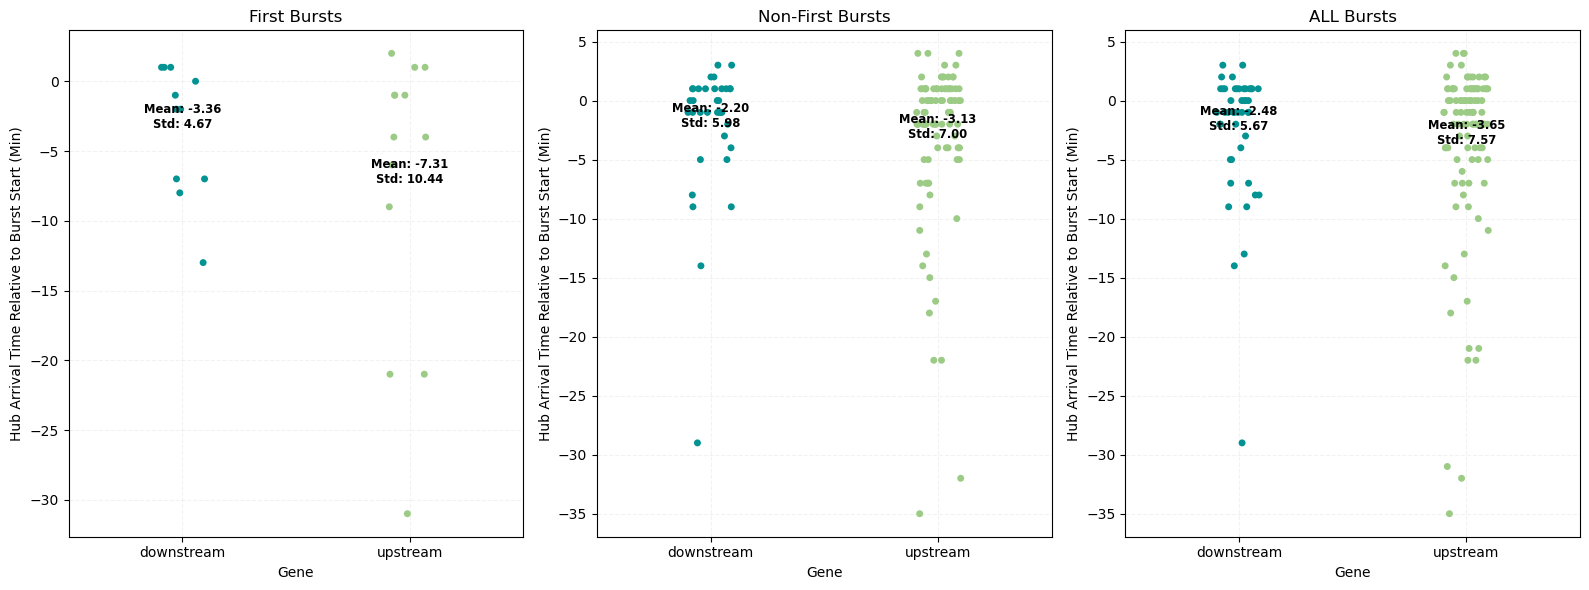

/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/1744209425.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/1744209425.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
/var/folders/p7/v7vf8_650m56bt_d_r00m1j8rzczds/T/ipykernel_66407/1744209425.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Gene', y='Hub_Interaction_D

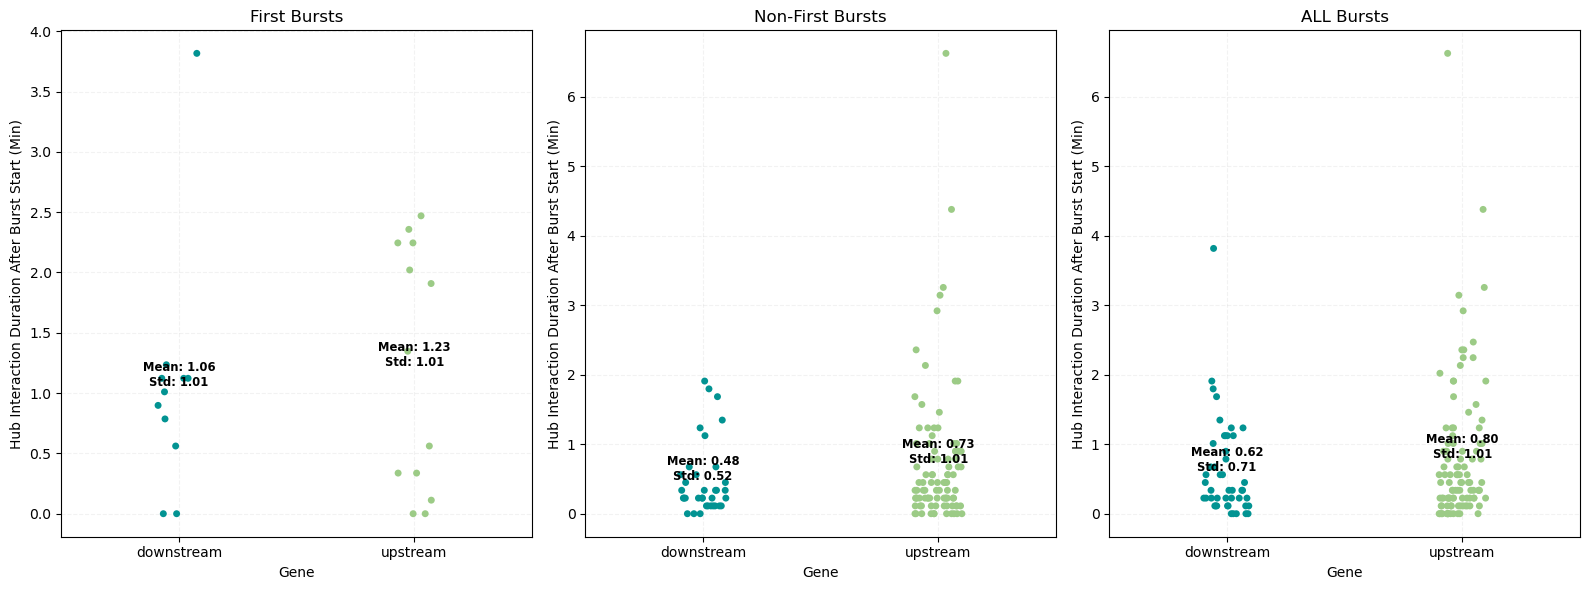

In [120]:
# Filter NC14
# all_bursts_dff = all_bursts_df[all_bursts_df['NC'] == 'NC14']
all_bursts_dff = all_bursts_df.copy()

# Jitter Dot Plots of Hub Arrival Time
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot for first bursts
axes[0].set_title('First Bursts')
sns.stripplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
              data=first_bursts, order=genes, palette=gene_colors, jitter=True, ax=axes[0])
axes[0].set_xlabel('Gene')
axes[0].set_ylabel('Hub Arrival Time Relative to Burst Start (Min)')
axes[0].grid(True, linestyle='--', alpha=0.1, color='gray')

# Calculate and display mean and standard deviation for first bursts
for gene in genes:
    subset = first_bursts[first_bursts['Gene'] == gene]
    mean_val = subset['Hub_Arrival_Time_Relative_To_Burst_Start_Min'].mean()
    std_val = subset['Hub_Arrival_Time_Relative_To_Burst_Start_Min'].std()
    axes[0].text(gene, mean_val, f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}', 
                 horizontalalignment='center', size='small', color='black', weight='semibold')

# Plot for non-first bursts
axes[1].set_title('Non-First Bursts')
sns.stripplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
              data=non_first_bursts, order=genes, palette=gene_colors, jitter=True, ax=axes[1])
axes[1].set_xlabel('Gene')
axes[1].set_ylabel('Hub Arrival Time Relative to Burst Start (Min)')
axes[1].grid(True, linestyle='--', alpha=0.1, color='gray')

# Calculate and display mean and standard deviation for non-first bursts
for gene in genes:
    subset = non_first_bursts[non_first_bursts['Gene'] == gene]
    mean_val = subset['Hub_Arrival_Time_Relative_To_Burst_Start_Min'].mean()
    std_val = subset['Hub_Arrival_Time_Relative_To_Burst_Start_Min'].std()
    axes[1].text(gene, mean_val, f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}', 
                 horizontalalignment='center', size='small', color='black', weight='semibold')

# Plot for all bursts
axes[2].set_title('ALL Bursts')
sns.stripplot(x='Gene', y='Hub_Arrival_Time_Relative_To_Burst_Start_Min',
              data=alll_bursts, order=genes, palette=gene_colors, jitter=True, ax=axes[2])
axes[2].set_xlabel('Gene')
axes[2].set_ylabel('Hub Arrival Time Relative to Burst Start (Min)')
axes[2].grid(True, linestyle='--', alpha=0.1, color='gray')

# Calculate and display mean and standard deviation for all bursts
for gene in genes:
    subset = alll_bursts[alll_bursts['Gene'] == gene]
    mean_val = subset['Hub_Arrival_Time_Relative_To_Burst_Start_Min'].mean()
    std_val = subset['Hub_Arrival_Time_Relative_To_Burst_Start_Min'].std()
    axes[2].text(gene, mean_val, f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}', 
                 horizontalalignment='center', size='small', color='black', weight='semibold')

plt.tight_layout()
# plt.savefig(os.path.join(figdir, f'Hub_Arrival_Jitter.svg'), format='svg', dpi=300)
plt.show()

# Jitter Dot Plots of Interaction Duration
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot for first bursts
axes[0].set_title('First Bursts')
sns.stripplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
              data=first_bursts, order=genes, palette=gene_colors, jitter=True, ax=axes[0])
axes[0].set_xlabel('Gene')
axes[0].set_ylabel('Hub Interaction Duration After Burst Start (Min)')
axes[0].grid(True, linestyle='--', alpha=0.1, color='gray')

# Calculate and display mean and standard deviation for first bursts
for gene in genes:
    subset = first_bursts[first_bursts['Gene'] == gene]
    mean_val = subset['Hub_Interaction_Duration_After_Burst_Start_Min'].mean()
    std_val = subset['Hub_Interaction_Duration_After_Burst_Start_Min'].std()
    axes[0].text(gene, mean_val, f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}', 
                 horizontalalignment='center', size='small', color='black', weight='semibold')

# Plot for non-first bursts
axes[1].set_title('Non-First Bursts')
sns.stripplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
              data=non_first_bursts, order=genes, palette=gene_colors, jitter=True, ax=axes[1])
axes[1].set_xlabel('Gene')
axes[1].set_ylabel('Hub Interaction Duration After Burst Start (Min)')
axes[1].grid(True, linestyle='--', alpha=0.1, color='gray')

# Calculate and display mean and standard deviation for non-first bursts
for gene in genes:
    subset = non_first_bursts[non_first_bursts['Gene'] == gene]
    mean_val = subset['Hub_Interaction_Duration_After_Burst_Start_Min'].mean()
    std_val = subset['Hub_Interaction_Duration_After_Burst_Start_Min'].std()
    axes[1].text(gene, mean_val, f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}', 
                 horizontalalignment='center', size='small', color='black', weight='semibold')

# Plot for all bursts
axes[2].set_title('ALL Bursts')
sns.stripplot(x='Gene', y='Hub_Interaction_Duration_After_Burst_Start_Min',
              data=alll_bursts, order=genes, palette=gene_colors, jitter=True, ax=axes[2])
axes[2].set_xlabel('Gene')
axes[2].set_ylabel('Hub Interaction Duration After Burst Start (Min)')
axes[2].grid(True, linestyle='--', alpha=0.1, color='gray')

# Calculate and display mean and standard deviation for all bursts
for gene in genes:
    subset = alll_bursts[alll_bursts['Gene'] == gene]
    mean_val = subset['Hub_Interaction_Duration_After_Burst_Start_Min'].mean()
    std_val = subset['Hub_Interaction_Duration_After_Burst_Start_Min'].std()
    axes[2].text(gene, mean_val, f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}', 
                 horizontalalignment='center', size='small', color='black', weight='semibold')

plt.tight_layout()
# plt.savefig(os.path.join(figdir, f'Hub_Duration_Jitter.svg'), format='svg', dpi=300)
plt.show()


In [133]:


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kendalltau, spearmanr, pearsonr
import os  # For saving figures
import seaborn as sns  # For bar plots
from scipy import stats

# Define lists of hub measurements and burst measurements
hub_measurements = [
    'Hub_Arrival_Time_Relative_To_Burst_Start_Frame',
    'Hub_Interaction_Duration_After_Burst_Start_Frame',
    'Smoothed_Mean_Intensity_pre',  # Replace with your actual column names
    # 'Smoothed_Mean_Intensity_during',
    # 'Smoothed_Mean_Intensity_post'
]
burst_measurements = ['Amplitude', 'Duration', 'Frequency', 'Output']

# Shortened Hub Measurement Names for Visualization
hub_measurement_names = {
    'Hub_Arrival_Time_Relative_To_Burst_Start_Frame': "Hub Arrival",
    'Hub_Interaction_Duration_After_Burst_Start_Frame': "Hub Duration",
    'Smoothed_Mean_Intensity_pre': "Dl Int. Pre",
    # 'Smoothed_Mean_Intensity_during': "Dl Int. During",  # If you use these
    # 'Smoothed_Mean_Intensity_post': "Dl Int. Post"      # Add them here too
}

# Removed target/non-target gene lists and the function that assigned them.
# We are now analyzing correlations for EACH gene individually

#Filter NC14
all_bursts_dff = all_bursts_df[all_bursts_df['NC']=='NC14'].copy()
all_bursts_dff = all_bursts_df.copy()
# Normalize amplitude PER GENE in all_bursts_dff
genes = all_bursts_dff['Gene'].unique()
for gene in genes:
    gene_df = all_bursts_dff[all_bursts_dff['Gene'] == gene].copy()
    # Handle cases where max equals min to avoid division by zero
    if gene_df['Amplitude'].max() == gene_df['Amplitude'].min():
        gene_df.loc[:, 'Amplitude'] = 0  # Or some other sensible default
    else:
        gene_df.loc[:, 'Amplitude'] = (gene_df['Amplitude'] - gene_df['Amplitude'].min()) / (
                gene_df['Amplitude'].max() - gene_df['Amplitude'].min())

    if gene_df['Output'].max() == gene_df['Output'].min():
        gene_df.loc[:, 'Output'] = 0  # Or some other sensible default
    else:
        gene_df.loc[:, 'Output'] = (gene_df['Output'] - gene_df['Output'].min()) / (
                gene_df['Output'].max() - gene_df['Output'].min())

    all_bursts_dff.update(gene_df)


# --- Statistical Analysis ---
def perform_stats(df, nc_group, replicate_level, measure):
    # Remove NaN values from the specified measure column
    df = df.dropna(subset=[measure]).copy() # Drop any NAN right away.
    # print(f"\n--- Statistical Analysis for {nc_group}, Replicate Level: {replicate_level} ---")

    # Group data by NC and Gene
    if replicate_level == 'points':
         grouped = df.groupby(['NC','Gene'])[measure]
    elif replicate_level == 'Unique_Labels':
        grouped = df.groupby(['NC','Gene', 'Unique_Label'])[measure].mean().groupby(['NC','Gene'])
    elif replicate_level == 'Filenames':
        grouped = df.groupby(['NC','Gene', 'Filename'])[measure].mean().groupby(['NC','Gene'])
    
    results = []

    # Iterate through all pairs of groups within each NC, doing a Mann-Whitney U test
    groups = list(grouped.groups.keys())
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
                group1_name = groups[i]
                group2_name = groups[j]
                
                # Check if groups have the same NC, if not move to next iteration
                if group1_name[0] != group2_name[0]:
                    continue

                group1 = grouped.get_group(group1_name)
                group2 = grouped.get_group(group2_name)

                # *** ADDED CHECK FOR VARIATION ***
                if np.std(group1) == 0 or np.std(group2) == 0:
                    print(f"WARNING: No variation in {group1_name} or {group2_name} for {measure}. Skipping Mann-Whitney U.")
                    u_stat_two, p_val_two = np.nan, np.nan
                    u_stat_less, p_val_less = np.nan, np.nan
                    u_stat_greater, p_val_greater = np.nan, np.nan
                    n1, n2 = len(group1), len(group2)
                    sig_two, sig_less, sig_greater = "N/A", "N/A", "N/A"
                    continue  # Skip to the next group comparison

                
                # Check if there is only one data point to remove errors
                if len(group1) < 2 or len(group2) < 2:
                    # print(f"  Skipping {group1_name} vs {group2_name} because of only one data point.")
                    u_stat_two, p_val_two = np.nan, np.nan
                    u_stat_less, p_val_less = np.nan, np.nan
                    u_stat_greater = np.nan, np.nan
                    n1, n2 = len(group1), len(group2)
                    sig_two, sig_less, sig_greater = "N/A", "N/A", "N/A"

                    continue

                # Perform the Mann-Whitney U tests, but handle insufficient data
                try:
                    if len(group1) >= 2 and len(group2) >= 2:
                        u_stat_two, p_val_two = stats.mannwhitneyu(group1, group2, alternative='two-sided')
                        u_stat_less, p_val_less = stats.mannwhitneyu(group1, group2, alternative='less')
                        u_stat_greater, p_val_greater = stats.mannwhitneyu(group1, group2, alternative='greater')
                    else:
                        u_stat_two, p_val_two = np.nan, np.nan
                        u_stat_less, p_val_less = np.nan, np.nan
                        u_stat_greater, p_val_greater = np.nan, np.nan

                except ValueError as e:
                    print(f"Mann-Whitney U test failed for {group1_name} vs {group2_name}: {e}")
                    u_stat_two, p_val_two = np.nan, np.nan
                    u_stat_less, p_val_less = np.nan, np.nan
                    u_stat_greater, p_val_greater = np.nan, np.nan

                # Store group sizes
                n1 = len(group1)
                n2 = len(group2)

                # Determine significance for each test
                sig_two = 'Yes' if (p_val_two is not np.nan and p_val_two < 0.05) else 'No'
                sig_less = 'Yes' if (p_val_less is not np.nan and p_val_less < 0.05) else 'No'
                sig_greater = 'Yes' if (p_val_greater is not np.nan and p_val_greater < 0.05) else 'No'
               
                # Store result in list

                #if n1 > 1 and n2 > 1: #Make sure N values are not less than one. Removing
                results.append({
                    'NC': nc_group,
                    'Replicate Level': replicate_level,
                    'Group 1': group1_name,
                    'Group 2': group2_name,
                    'N1': n1,
                    'N2': n2,
                    'U-statistic (two-sided)': u_stat_two,
                    'p-value (two-sided)': p_val_two,
                    'Significant (two-sided)': sig_two,
                    'U-statistic (less)': u_stat_less,
                    'p-value (less)': p_val_less,
                    'Significant (less)': sig_less,
                    'U-statistic (greater)': u_stat_greater,
                    'p-value (greater)': p_val_greater,
                    'Significant (greater)': sig_greater
                })
                #else: #Removing
                    #print ("Skipping because there is only one data point.")
    return pd.DataFrame(results)

# Initialize an empty DataFrame to hold results
results_df = pd.DataFrame(columns=['NC', 'Replicate Level', 'Group 1', 'Group 2', 't-statistic', 'p-value', 'N1', 'N2', 'Significant'])

# # Analysis for NC13
# nc13_df = merged_df_filtered[merged_df_filtered['NC'] == 'NC13']
# for replicate_level in ['points', 'Unique_Labels', 'Filenames']:
#     results_df = pd.concat([results_df, perform_stats(nc13_df, 'NC13', replicate_level, measure)], ignore_index=True)

# Analysis for NC14
measure = 'Hub_Arrival_Time_Relative_To_Burst_Start_Min'
measure = 'Hub_Interaction_Duration_After_Burst_Start_Min'
measure = 'Smoothed_Mean_Intensity_pre'
nc14_df = all_bursts_dff[all_bursts_dff['NC'] == 'NC14']
for replicate_level in ['points', 'Unique_Labels', 'Filenames']:
    results_df = pd.concat([results_df, perform_stats(nc14_df, 'NC14', replicate_level, measure)], ignore_index=True)

# # Output to CSV file
# output_csv = f'/Volumes/mirlab/S/Dorsal MS/Statistics_CSVs/stats_{measure}.csv'
# results_df.to_csv(output_csv, index=False)
# print(f"\nStatistical results saved to {output_csv}")
print(results_df)

     NC Replicate Level             Group 1           Group 2 t-statistic  \
0  NC14          points  (NC14, downstream)  (NC14, upstream)         NaN   
1  NC14   Unique_Labels  (NC14, downstream)  (NC14, upstream)         NaN   
2  NC14       Filenames  (NC14, downstream)  (NC14, upstream)         NaN   

  p-value  N1   N2 Significant  U-statistic (two-sided)  p-value (two-sided)  \
0     NaN  52  108         NaN                   3283.0             0.083877   
1     NaN  16   17         NaN                    155.0             0.505152   
2     NaN   3    3         NaN                      7.0             0.400000   

  Significant (two-sided)  U-statistic (less)  p-value (less)  \
0                      No              3283.0        0.958387   
1                      No               155.0        0.758794   
2                      No                 7.0        0.900000   

  Significant (less)  U-statistic (greater)  p-value (greater)  \
0                 No                 3283.0